 # Operational Patterns and Weather Impacts in NYC 311 Complaints


#### Introduction

New York City agencies receive large volumes of 311 complaints each day across a wide range of service categories, including noise, sanitation, infrastructure, and housing-related issues. Because complaint volume and resolution speed fluctuate over time, city agencies face challenges in efficiently allocating operational resources and identifying periods of elevated strain.

This project analyzes NYC 311 complaint data to better understand the operational drivers behind complaint surges and delayed resolution times. Specifically, the analysis investigates how complaint type, geography, seasonality, and weather conditions influence both complaint volume and complaint resolution speed. The project also evaluates whether “bad operational days” — days with unusually high complaint volume or slow response times — tend to persist over time rather than occurring randomly.

To support this analysis, NYC 311 complaint data was merged with NOAA weather data. Python and SQL were used throughout the project for data cleaning, feature engineering, exploratory analysis, and predictive modeling.

The intended audience for this analysis is NYC municipal leadership and city operations teams to help them better anticipate operational strain, allocate resources more effectively, and identify complaint categories most vulnerable to delays during disruptive conditions.

#### Research Questions

Questions we sought to explore through this analysis include the following:

- Which complaint categories contribute most to operational burden and delayed resolution times?
- How do complaint patterns vary across boroughs, seasons, and time periods?
- Are high-volume or slow-response complaint days isolated events, or do they tend to cluster over time?
- Which complaint types are most sensitive to weather conditions?
- To what extent can weather and historical complaint patterns help predict operationally difficult days?

In [1]:
import requests
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import calendar

#### Data Collection

Data was collected using the NYC Open Data 311 API. To ensure a representative sample across time, complaints were pulled at the daily level within each month and then randomly sampled to maintain a consistent number of observations per month.

This approach avoids bias toward the beginning of each month, which can occur when pulling records in chronological order. The project uses two versions of NYC 311 data. First, a balanced row-level sample of approximately 800 complaints per month was collected to support complaint-type, borough, and resolution-time analysis. Because this sampling approach smooths complaint volume by design, a separate API query was used to pull true daily complaint counts for all of 2025. All analyses involving complaint volume use the true daily count dataset, while analyses involving complaint characteristics and resolution time use the sampled complaint-level dataset.

> **Sampling note:** While a full pull of all 2025 complaints would number in the hundreds of thousands, 800 complaints per month provides sufficient coverage of the complaint mix across all 12 months for resolution-time and category analyses. Because the API caps per-request results, this stratified daily approach is both practical and statistically sound. Crucially, all volume analyses (e.g., daily complaint totals, seasonal trends) use the *true* daily counts query, not the sampled data — so the tradeoff does not affect volume-based findings.


In [2]:
url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json"

# 800-per-month sample 

target_per_month = 800
all_data = []

for month in range(1, 13):
    days_in_month = calendar.monthrange(2025, month)[1]
    target_per_day = target_per_month // days_in_month + 1
    
    month_data = []

    for day in range(1, days_in_month + 1):
        start = f"2025-{month:02d}-{day:02d}T00:00:00"
        
        if day < days_in_month:
            end = f"2025-{month:02d}-{day+1:02d}T00:00:00"
        elif month < 12:
            end = f"2025-{month+1:02d}-01T00:00:00"
        else:
            end = "2026-01-01T00:00:00"

        params = {
            "$where": f"created_date >= '{start}' AND created_date < '{end}'",
            "$limit": target_per_day
        }

        rows = requests.get(url, params=params, timeout=30).json()
        month_data.extend(rows)

    month_df = pd.DataFrame(month_data)

    if len(month_df) > target_per_month:
        month_df = month_df.sample(n=target_per_month, random_state=42)

    print(f"Month {month}: kept={len(month_df)}")
    all_data.append(month_df)

NYC = pd.concat(all_data, ignore_index=True)

print("Total rows:", len(NYC))

Month 1: kept=800
Month 2: kept=800
Month 3: kept=800
Month 4: kept=800
Month 5: kept=800
Month 6: kept=800
Month 7: kept=800
Month 8: kept=800
Month 9: kept=800
Month 10: kept=800
Month 11: kept=800
Month 12: kept=800
Total rows: 9600


In [3]:
import time

all_true_counts = []

for month in range(1, 13):
    
    start_date = f"2025-{month:02d}-01T00:00:00"
    
    if month < 12:
        end_date = f"2025-{month + 1:02d}-01T00:00:00"
    else:
        end_date = "2026-01-01T00:00:00"
    
    params = {
        "$select": "date_trunc_ymd(created_date) as date_only, borough, count(unique_key) as true_complaint_count",
        "$where": f"created_date >= '{start_date}' AND created_date < '{end_date}'",
        "$group": "date_trunc_ymd(created_date), borough",
        "$order": "date_only",
        "$limit": 5000
    }
    
    response = requests.get(url, params=params, timeout=60)
    
    print(month, response.status_code)
    
    month_df = pd.DataFrame(response.json())
    
    all_true_counts.append(month_df)
    
    time.sleep(0.5)

NYC_true = pd.concat(all_true_counts, ignore_index=True)

NYC_true.head()

1 200
2 200
3 200
4 200
5 200
6 200
7 200
8 200
9 200
10 200
11 200
12 200


,date_only,borough,true_complaint_count
0,2025-01-01T00:00:00.000,BRONX,4803
1,2025-01-01T00:00:00.000,BROOKLYN,2369
2,2025-01-01T00:00:00.000,MANHATTAN,1454
3,2025-01-01T00:00:00.000,QUEENS,1944
4,2025-01-01T00:00:00.000,STATEN ISLAND,295


In [4]:
# Clean NYC_true

NYC_true["date_only"] = pd.to_datetime(NYC_true["date_only"])

NYC_true["borough"] = (
    NYC_true["borough"]
    .str.strip()
    .str.title()
)

NYC_true["true_complaint_count"] = (
    NYC_true["true_complaint_count"]
    .astype(int)
)

NYC_true = NYC_true[
    NYC_true["borough"].notna() &
    (NYC_true["borough"] != "Unspecified")
]

NYC_true.head()

,date_only,borough,true_complaint_count
0,2025-01-01,Bronx,4803
1,2025-01-01,Brooklyn,2369
2,2025-01-01,Manhattan,1454
3,2025-01-01,Queens,1944
4,2025-01-01,Staten Island,295


In [5]:
# True daily complaint counts across all boroughs

true_daily_counts = (
    NYC_true
    .groupby("date_only")["true_complaint_count"]
    .sum()
    .reset_index()
)

true_daily_counts.head()

,date_only,true_complaint_count
0,2025-01-01,10865
1,2025-01-02,13807
2,2025-01-03,11677
3,2025-01-04,11453
4,2025-01-05,13572


In [6]:
NYC_true["month"] = NYC_true["date_only"].dt.month

In [7]:
true_daily_counts.shape

(365, 2)

In [8]:
NYC_true["month"].value_counts().sort_index()

month
1     155
2     140
3     155
4     150
5     155
6     150
7     155
8     155
9     150
10    155
11    150
12    155
Name: count, dtype: int64

In [9]:
NYC["created_date"] = pd.to_datetime(NYC["created_date"])
NYC["date_only"] = NYC["created_date"].dt.date
NYC["day_of_month"] = NYC["created_date"].dt.day

NYC["day_of_month"].value_counts().sort_index()

day_of_month
1     314
2     319
3     307
4     302
5     307
6     319
7     319
8     318
9     319
10    318
11    308
12    318
13    319
14    319
15    319
16    318
17    307
18    315
19    319
20    319
21    319
22    318
23    315
24    319
25    318
26    315
27    312
28    319
29    290
30    290
31    182
Name: count, dtype: int64

In [10]:
NYC.info()

<class 'pandas.DataFrame'>
RangeIndex: 9600 entries, 0 to 9599
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   unique_key                      9600 non-null   str           
 1   created_date                    9600 non-null   datetime64[us]
 2   closed_date                     9544 non-null   str           
 3   agency                          9600 non-null   str           
 4   agency_name                     9600 non-null   str           
 5   complaint_type                  9600 non-null   str           
 6   descriptor                      9597 non-null   str           
 7   location_type                   9024 non-null   str           
 8   incident_zip                    9543 non-null   str           
 9   incident_address                9404 non-null   str           
 10  street_name                     9399 non-null   str           
 11  cross_street_1 

In [11]:
NYC.sample(10)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,incident_address,...,vehicle_type,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,taxi_company_borough,due_date,date_only,day_of_month
4826,65577928,2025-07-16 00:00:00,2025-08-29T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,3 or More,Restaurant/Bar/Deli/Bakery,11215,367 7 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07-16,16
9070,67007763,2025-12-01 00:02:29,2026-02-07T13:35:19.000,HPD,Department of Housing Preservation and Develop...,UNSANITARY CONDITION,MOLD,RESIDENTIAL BUILDING,10009,32 AVENUE B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-01,1
618,63727459,2025-01-11 00:00:00,2025-01-13T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Restaurant/Bar/Deli/Bakery,11220,6115 5 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-11,11
4961,65610347,2025-07-20 00:01:13,2025-07-20T00:16:12.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10457,1772 MONROE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07-20,20
6764,66282854,2025-09-26 00:00:00,2026-02-11T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Restaurant/Bar/Deli/Bakery,10011,182 8 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-26,26
7966,66622355,2025-10-27 00:01:58,2025-10-27T00:15:31.000,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11220,332 55 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-27,27
1208,64035251,2025-02-10 00:00:00,2025-02-14T00:00:01.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Cafeteria - College/University,10012,45 WEST 4 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02-10,10
1994,64404766,2025-03-20 00:02:06,2025-03-20T09:48:14.000,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,11234,EAST 34 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-03-20,20
9230,67250828,2025-12-21 00:01:30,2025-12-21T08:50:42.000,NYPD,New York City Police Department,Illegal Parking,Blocked Hydrant,Street/Sidewalk,11379,61-66 71 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-21,21
4937,65632070,2025-07-22 00:00:00,2026-04-03T13:18:10.000,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Other (Explain Below),10282,210 MURRAY STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07-22,22


## 1. Data Cleaning

Key preprocessing steps included:
- Converting date fields to datetime format
- Removing or handling missing values
- Creating a resolution time variable (`hours_to_close`)
- Extracting time-based features such as month and day

Resolution time is highly skewed, so both mean and median values are considered in later analysis, with greater emphasis placed on the median to better reflect the typical case.

In [12]:
#look for missing values 

NYC.isna().sum()

unique_key                           0
created_date                         0
closed_date                         56
agency                               0
agency_name                          0
complaint_type                       0
descriptor                           3
location_type                      576
incident_zip                        57
incident_address                   196
street_name                        201
cross_street_1                    1388
cross_street_2                    1386
intersection_street_1             1531
intersection_street_2             1528
address_type                        27
city                               272
landmark                          1976
status                               0
resolution_description              45
resolution_action_updated_date      31
community_board                      0
council_district                   110
police_precinct                      0
bbl                                753
borough                  

In [13]:
# Quantify missingness before deciding what to drop

missing_initial = pd.DataFrame({
"missing_count": NYC.isna().sum(),
"missing_pct": (NYC.isna().sum() / len(NYC) * 100).round(1)
}).sort_values("missing_pct", ascending=False)

missing_initial.head(25)

,missing_count,missing_pct
taxi_company_borough,9597,100.0
road_ramp,9588,99.9
bridge_highway_direction,9584,99.8
due_date,9578,99.8
bridge_highway_name,9571,99.7
bridge_highway_segment,9571,99.7
taxi_pick_up_location,9543,99.4
vehicle_type,9299,96.9
facility_type,9154,95.4
descriptor_2,7668,79.9


In [14]:
#drop columns that are unusable / largely missing (>80% missing) or not relevant to our analysis (ex. intersection_street_2)

cols_to_drop = [
    "descriptor_2",
    "facility_type",
    "vehicle_type",
    "bridge_highway_name",
    "bridge_highway_direction",
    "bridge_highway_segment",
    "taxi_pick_up_location",
    "road_ramp",
    "due_date",
    "taxi_company_borough",
    "landmark",
    "intersection_street_2",
    "intersection_street_1",
    "cross_street_1",
    "cross_street_2",
    "bbl",
    "location_type",
]
NYC = NYC.drop(columns=cols_to_drop, errors="ignore")

In [15]:
#dropped columns with >80% missing values

NYC.isna().sum()

unique_key                          0
created_date                        0
closed_date                        56
agency                              0
agency_name                         0
complaint_type                      0
descriptor                          3
incident_zip                       57
incident_address                  196
street_name                       201
address_type                       27
city                              272
status                              0
resolution_description             45
resolution_action_updated_date     31
community_board                     0
council_district                  110
police_precinct                     0
borough                             0
x_coordinate_state_plane           83
y_coordinate_state_plane           83
open_data_channel_type              0
park_facility_name                  0
park_borough                        0
latitude                           83
longitude                          83
location    

Columns with high missingness (>80%) or those not relevant to the analysis were removed to improve data quality and interpretability.

In [16]:
#replace missing values with "unknown" and remove "unspecified values" for borough since there is an insignificant number (6 rows)
#did not do this for date/time related entries, given missing data is information in itself (e.g., has not been closed yet)
NYC["descriptor"] = NYC["descriptor"].fillna("Unknown")
NYC["borough"] = NYC["borough"].fillna("Unknown")
NYC["status"] = NYC["status"].fillna("Unknown")
NYC = NYC[NYC['borough'].str.lower() != 'unspecified']

In [17]:
#drop duplicates
before = len(NYC)
NYC = NYC.drop_duplicates(subset=["unique_key"])
print(f"Dropped {before - len(NYC)} duplicate rows based on unique_key")

#used unique_key as primary identifer for compalints. Using timestamp/type/borough could remove legitimate compalaints that are distinct, just occuring at the same time.

Dropped 0 duplicate rows based on unique_key


In [18]:
#standardize text - remove spaces and standardize casing

NYC["complaint_type"] = NYC["complaint_type"].str.strip()
NYC["descriptor"] = NYC["descriptor"].str.strip()
NYC["borough"] = NYC["borough"].str.upper()

In [19]:
#only keeps rows where created_date is not missing
NYC = NYC[NYC["created_date"].notna()]


In [20]:
#convert string dates to datetime so we can perform time based analysis

NYC["created_date"] = pd.to_datetime(NYC["created_date"], errors="coerce")
NYC["closed_date"] = pd.to_datetime(NYC["closed_date"], errors="coerce")



In [21]:
#add column on hours to close - how many hours passed between when complaint was created and when it closed
NYC["hours_to_close"] = (
    NYC["closed_date"] - NYC["created_date"]
).dt.total_seconds() / 3600

In [22]:
# Sanity check: resolution time should not be negative
print(NYC["hours_to_close"].describe())
print("Negative hours_to_close rows:", (NYC["hours_to_close"] < 0).sum())

count     9528.000000
mean       362.644656
std       1305.723976
min          0.000000
25%          0.735833
50%          2.839861
75%         38.587292
max      10138.530556
Name: hours_to_close, dtype: float64
Negative hours_to_close rows: 0


In [23]:
NYC.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,incident_zip,incident_address,street_name,...,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,latitude,longitude,location,date_only,day_of_month,hours_to_close
0,63906276,2025-01-27 00:02:55,2025-02-23 15:37:18,HPD,Department of Housing Preservation and Develop...,UNSANITARY CONDITION,PESTS,11422,258-07 FRANCIS LEWIS BOULEVARD,FRANCIS LEWIS BOULEVARD,...,179108,PHONE,Unspecified,QUEENS,40.657967149938735,-73.72883190302234,"{'type': 'Point', 'coordinates': [-73.72883190...",2025-01-27,27,663.573056
1,63728951,2025-01-12 00:00:21,2025-01-12 03:12:30,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Talking,10467,3591 BAINBRIDGE AVENUE,BAINBRIDGE AVENUE,...,261344,MOBILE,Unspecified,BRONX,40.88393820035715,-73.87768506536197,"{'type': 'Point', 'coordinates': [-73.87768506...",2025-01-12,12,3.202500
2,63697539,2025-01-09 00:01:35,2025-01-09 10:01:18,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,10466,655 EAST 230 STREET,EAST 230 STREET,...,264242,MOBILE,Unspecified,BRONX,40.89187241649303,-73.86016845296459,"{'type': 'Point', 'coordinates': [-73.86016845...",2025-01-09,9,9.995278
3,63744605,2025-01-13 00:02:17,2025-01-13 07:53:29,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,10466,655 EAST 230 STREET,EAST 230 STREET,...,264242,MOBILE,Unspecified,BRONX,40.89187241649303,-73.86016845296459,"{'type': 'Point', 'coordinates': [-73.86016845...",2025-01-13,13,7.853333
4,63839233,2025-01-21 00:02:36,2025-01-26 17:19:09,HPD,Department of Housing Preservation and Develop...,ELECTRIC,NO LIGHTING,10467,855 EAST 217 STREET,EAST 217 STREET,...,260196,PHONE,Unspecified,BRONX,40.88076617705628,-73.8591611769796,"{'type': 'Point', 'coordinates': [-73.85916117...",2025-01-21,21,137.275833


In [24]:
NYC.info()

<class 'pandas.DataFrame'>
Index: 9582 entries, 0 to 9599
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   unique_key                      9582 non-null   str           
 1   created_date                    9582 non-null   datetime64[us]
 2   closed_date                     9528 non-null   datetime64[us]
 3   agency                          9582 non-null   str           
 4   agency_name                     9582 non-null   str           
 5   complaint_type                  9582 non-null   str           
 6   descriptor                      9582 non-null   str           
 7   incident_zip                    9543 non-null   str           
 8   incident_address                9403 non-null   str           
 9   street_name                     9398 non-null   str           
 10  address_type                    9561 non-null   str           
 11  city                

In [25]:
#check missing values (count + %)
missing_counts = NYC.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(NYC)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
})

missing_df.head(15)

,missing_count,missing_pct
city,254,2.650804
street_name,184,1.920267
incident_address,179,1.868086
council_district,92,0.960134
x_coordinate_state_plane,66,0.688791
y_coordinate_state_plane,66,0.688791
longitude,66,0.688791
latitude,66,0.688791
location,66,0.688791
hours_to_close,54,0.563557


In [26]:
NYC.describe(include="all")

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,incident_zip,incident_address,street_name,...,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,latitude,longitude,location,date_only,day_of_month,hours_to_close
count,9582,9582,9528,9582,9582,9582,9582,9543,9403,9398,...,9516,9582,9582,9582,9516,9516,9516,9582,9582.000000,9528.000000
unique,9582,NaN,NaN,13,13,111,328,192,7501,2336,...,7324,4,27,5,7619,7619,7619,365,NaN,NaN
top,63906276,NaN,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,10466,655 EAST 230 STREET,EAST 230 STREET,...,264242,ONLINE,Unspecified,BROOKLYN,40.89187241649303,-73.86016845296459,"{'type': 'Point', 'coordinates': [-73.86016845...",2025-02-28,NaN,NaN
freq,1,NaN,NaN,5485,5485,2030,2480,370,276,303,...,276,4231,9531,2772,276,276,276,29,NaN,NaN
mean,NaN,2025-07-01 06:45:55.872782,2025-07-16 01:18:26.074727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.745878,362.644656
min,NaN,2025-01-01 00:00:12,2025-01-01 00:02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000
25%,NaN,2025-04-01 00:00:01.500000,2025-04-08 04:54:10.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,0.735833
50%,NaN,2025-07-01 00:00:27.500000,2025-07-14 00:00:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.000000,2.839861
75%,NaN,2025-09-30 18:01:35.250000,2025-10-19 02:22:16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000,38.587292
max,NaN,2025-12-31 00:02:40,2026-05-15 06:14:23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.000000,10138.530556


In [27]:
#flag whether complaint is closed
NYC["is_closed"] = NYC["closed_date"].notna().astype(int)

In [28]:
#check open complaints
NYC["is_closed"].value_counts()

is_closed
1    9528
0      54
Name: count, dtype: int64

In [29]:
#check current columns
NYC.columns

Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'incident_zip', 'incident_address',
       'street_name', 'address_type', 'city', 'status',
       'resolution_description', 'resolution_action_updated_date',
       'community_board', 'council_district', 'police_precinct', 'borough',
       'x_coordinate_state_plane', 'y_coordinate_state_plane',
       'open_data_channel_type', 'park_facility_name', 'park_borough',
       'latitude', 'longitude', 'location', 'date_only', 'day_of_month',
       'hours_to_close', 'is_closed'],
      dtype='str')

In [30]:
#extract time features
NYC["year"] = NYC["created_date"].dt.year
NYC["month"] = NYC["created_date"].dt.month
NYC["day_of_week"] = NYC["created_date"].dt.day_name()

In [31]:
#categorize resolution speed
NYC["resolution_speed"] = NYC["hours_to_close"].apply(
    lambda x: "fast" if x <= 24 else ("medium" if x <= 168 else "slow") if pd.notna(x) else "open"
)
NYC["resolution_speed"].value_counts()

resolution_speed
fast      6565
medium    1615
slow      1348
open        54
Name: count, dtype: int64

In [32]:
#group top complaint types
top_types = NYC["complaint_type"].value_counts().head(10).index

NYC["complaint_group"] = NYC["complaint_type"].apply(
    lambda x: x if x in top_types else "Other"
)

In [33]:
#weekend vs weekday
NYC["is_weekend"] = NYC["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

The `is_weekend` flag distinguishes Saturday/Sunday complaints from weekday complaints. Weekend days may have different complaint mixes — enforcement-driven issues (illegal parking, noise) are more likely to peak on weekdays when parking regulations are active and weekday business hours apply, while leisure and social activity-related noise may peak on weekends. This feature will be used later in the EDA to test whether day type meaningfully affects resolution speed.


In [34]:
NYC.sample(10)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,incident_zip,incident_address,street_name,...,date_only,day_of_month,hours_to_close,is_closed,year,month,day_of_week,resolution_speed,complaint_group,is_weekend
103,63778471,2025-01-16 00:00:00,2025-01-16 05:21:24,NYPD,New York City Police Department,Abandoned Vehicle,With License Plate,11210,1485 EAST 23 STREET,EAST 23 STREET,...,2025-01-16,16,5.356667,1,2025,1,Thursday,fast,Other,0
3541,64904798,2025-05-10 00:02:29,2025-05-10 00:07:31,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,10457,1872 MONROE AVENUE,MONROE AVENUE,...,2025-05-10,10,0.083889,1,2025,5,Saturday,fast,Noise - Residential,1
5115,65689353,2025-07-28 00:00:26,2025-07-28 06:53:13,NYPD,New York City Police Department,Illegal Parking,Double Parked Blocking Traffic,10466,4315 BRUNER AVENUE,BRUNER AVENUE,...,2025-07-28,28,6.879722,1,2025,7,Monday,fast,Illegal Parking,0
4450,65405931,2025-06-28 00:02:00,2025-07-03 14:55:00,DEP,Department of Environmental Protection,Noise,Noise: Private Carting Noise (NQ1),10010,4 WEST 24 STREET,WEST 24 STREET,...,2025-06-28,28,134.883333,1,2025,6,Saturday,medium,Noise,1
4910,65661832,2025-07-25 00:00:00,2025-07-28 00:00:01,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,11385,59-22 MYRTLE AVENUE,MYRTLE AVENUE,...,2025-07-25,25,72.000278,1,2025,7,Friday,medium,Food Poisoning,0
6187,67755108,2025-08-13 00:02:02,2025-08-17 09:52:16,HPD,Department of Housing Preservation and Develop...,UNSANITARY CONDITION,MOLD,11216,302 QUINCY STREET,QUINCY STREET,...,2025-08-13,13,105.837222,1,2025,8,Wednesday,medium,UNSANITARY CONDITION,0
6669,66133080,2025-09-13 00:00:59,2025-09-13 01:49:05,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,10032,500 WEST 171 STREET,WEST 171 STREET,...,2025-09-13,13,1.801667,1,2025,9,Saturday,fast,Noise - Street/Sidewalk,1
1644,64343523,2025-03-14 00:01:59,2025-03-14 13:43:11,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,11367,71-30 150 STREET,150 STREET,...,2025-03-14,14,13.686667,1,2025,3,Friday,fast,Noise - Residential,0
3192,64554938,2025-04-05 00:01:20,2025-04-05 02:22:18,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,10458,EAST 197 STREET,EAST 197 STREET,...,2025-04-05,5,2.349444,1,2025,4,Saturday,fast,Noise - Street/Sidewalk,1
9086,67231863,2025-12-18 00:00:00,2025-12-18 00:00:01,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,10023,247 COLUMBUS AVENUE,COLUMBUS AVENUE,...,2025-12-18,18,0.000278,1,2025,12,Thursday,fast,Food Poisoning,0


In [35]:
# outlier check
NYC["hours_to_close"].describe()
NYC["hours_to_close"].quantile([0.5, 0.9, 0.95, 0.99])

0.50       2.839861
0.90     600.000278
0.95    2328.000278
0.99    8201.520278
Name: hours_to_close, dtype: float64

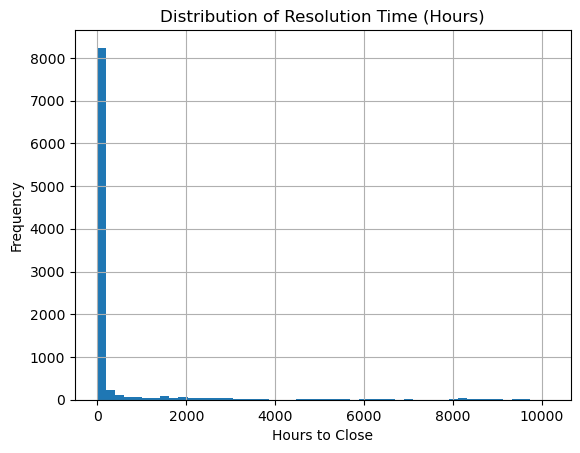

In [36]:
NYC["hours_to_close"].hist(bins=50)
plt.title("Distribution of Resolution Time (Hours)")
plt.xlabel("Hours to Close")
plt.ylabel("Frequency")
plt.show()

Resolution time is highly right-skewed, with extreme values at the upper percentiles. This suggests that the mean may be sensitive to outliers, so median will be used for most comparisons.

## 2. Complaint Type × Borough Interaction
To understand how resolution time is shaped by both issue type and location, this section compares complaint mix and **median** resolution time across boroughs and complaint categories. Median is used because the earlier distribution check showed that `hours_to_close` is heavily right-skewed.

In [37]:
# Count complaints per borough

borough_counts = (
    NYC_true
    .groupby("borough")["true_complaint_count"]
    .sum()
    .reset_index(name="complaints_count")
    .sort_values("complaints_count", ascending=False)
)

borough_counts

,borough,complaints_count
1,Brooklyn,1078327
3,Queens,878212
0,Bronx,836505
2,Manhattan,725036
4,Staten Island,134302


In [62]:
#top complaint types
top_types = NYC["complaint_type"].value_counts().head(10).index

NYC_top = NYC[NYC["complaint_type"].isin(top_types)]

top_types

Index(['Noise - Residential', 'Food Poisoning', 'Illegal Parking',
       'Noise - Street/Sidewalk', 'HEAT/HOT WATER', 'Noise - Commercial',
       'Blocked Driveway', 'Noise', 'Noise - Vehicle', 'UNSANITARY CONDITION'],
      dtype='str', name='complaint_type')

In [39]:
#complaint distribution by borough
NYC.groupby("borough")["complaint_type"].value_counts().unstack()

complaint_type,AHV Inspection Unit,APPLIANCE,Abandoned Bike,Abandoned Vehicle,Air Quality,Animal Facility - No Permit,Animal in a Park,Animal-Abuse,Asbestos,Bike Rack,...,Traffic Signal Condition,UNSANITARY CONDITION,Unleashed Dog,Unsanitary Animal Pvt Property,Urinating in Public,Vendor Enforcement,Violation of Park Rules,WATER LEAK,Water Conservation,Water System
borough,,,,,,,,,,,,,,,,,,,,,
BRONX,NaN,2.0,NaN,8.0,1.0,NaN,NaN,4.0,NaN,NaN,...,15.0,44.0,NaN,1.0,NaN,NaN,NaN,9.0,1.0,19.0
BROOKLYN,NaN,3.0,NaN,21.0,5.0,NaN,1.0,7.0,NaN,1.0,...,24.0,43.0,1.0,NaN,1.0,3.0,1.0,23.0,NaN,18.0
MANHATTAN,1.0,1.0,NaN,4.0,1.0,NaN,NaN,1.0,1.0,1.0,...,15.0,20.0,1.0,NaN,1.0,5.0,NaN,7.0,1.0,9.0
QUEENS,NaN,NaN,1.0,23.0,3.0,1.0,1.0,4.0,NaN,NaN,...,20.0,12.0,NaN,3.0,2.0,1.0,NaN,7.0,NaN,11.0
STATEN ISLAND,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,...,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0


Complaint patterns vary significantly by borough — Brooklyn and Queens are the highest-volume boroughs in absolute terms, but the composition of complaints differs meaningfully across locations. This matters for our research question because it means that citywide averages mask important geographic heterogeneity: a one-size-fits-all staffing or response strategy would miss the distinct demands of each borough. Understanding which categories dominate where allows operations teams to pre-position resources more effectively.


In [40]:
# Find the top 3 most common complaint types within each borough

top3_complaints_by_borough = (
    NYC
    .groupby(["borough", "complaint_type"])
    .agg(
        sampled_volume=("unique_key", "count"),
        median_hours_to_close=("hours_to_close", "median")
    )
    .reset_index()
)

top3_complaints_by_borough = (
    top3_complaints_by_borough
    .sort_values(["borough", "sampled_volume"], ascending=[True, False])
    .groupby("borough")
    .head(3)
    .sort_values(["borough", "sampled_volume"], ascending=[True, False])
)

top3_complaints_by_borough

,borough,complaint_type,sampled_volume,median_hours_to_close
40,BRONX,Noise - Residential,685,2.051944
41,BRONX,Noise - Street/Sidewalk,225,0.985556
27,BRONX,HEAT/HOT WATER,216,34.581944
123,BROOKLYN,Noise - Residential,544,0.839167
99,BROOKLYN,Food Poisoning,457,48.000278
109,BROOKLYN,Illegal Parking,455,1.728611
184,MANHATTAN,Food Poisoning,841,48.000278
206,MANHATTAN,Noise - Residential,347,0.861667
207,MANHATTAN,Noise - Street/Sidewalk,290,0.736250
276,QUEENS,Illegal Parking,408,2.315694


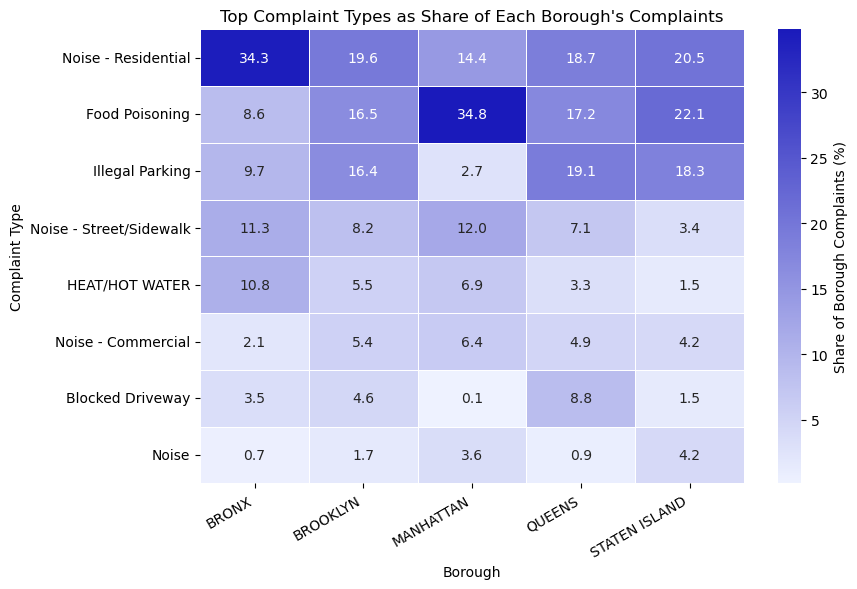

In [63]:
# Heat map of top complaint type share within each borough
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

top_types = (
    NYC["complaint_type"]
    .value_counts()
    .head(8)
    .index
)

# Count complaint types by borough
borough_type_counts = (
    NYC[NYC["complaint_type"].isin(top_types)]
    .groupby(["borough", "complaint_type"])
    .size()
    .reset_index(name="sampled_volume")
)

# Count total complaints within each borough
borough_totals = (
    NYC
    .groupby("borough")
    .size()
    .reset_index(name="total_borough_complaints")
)

# Merge borough totals into complaint-type counts
borough_type_counts = borough_type_counts.merge(
    borough_totals,
    on="borough",
    how="left"
)

# Calculate each complaint type as a share of that borough's complaints
borough_type_counts["share_of_borough"] = (
    borough_type_counts["sampled_volume"] /
    borough_type_counts["total_borough_complaints"] *
    100
)

borough_type_pivot = borough_type_counts.pivot(
    index="complaint_type",
    columns="borough",
    values="share_of_borough"
).fillna(0)

borough_type_pivot = borough_type_pivot.reindex(top_types)

custom_blues = LinearSegmentedColormap.from_list(
    "custom_blues",
    ["#eef2ff", "#1a1abb"]
)

plt.figure(figsize=(9, 6))

sns.heatmap(
    borough_type_pivot,
    annot=True,
    fmt=".1f",
    cmap=custom_blues,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Share of Borough Complaints (%)"}
)

plt.title("Top Complaint Types as Share of Each Borough's Complaints")
plt.xlabel("Borough")
plt.ylabel("Complaint Type")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("complaint_type_borough_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [64]:
# Check Food Poisoning counts and shares by borough

food_check = (
    NYC[NYC["complaint_type"] == "Food Poisoning"]
    .groupby("borough")
    .agg(
        food_poisoning_count=("unique_key", "count")
    )
    .reset_index()
)

borough_total_check = (
    NYC
    .groupby("borough")
    .agg(
        total_sampled_complaints=("unique_key", "count")
    )
    .reset_index()
)

food_check = food_check.merge(
    borough_total_check,
    on="borough",
    how="left"
)

food_check["food_poisoning_share"] = (
    food_check["food_poisoning_count"] /
    food_check["total_sampled_complaints"] *
    100
)

food_check.sort_values("food_poisoning_share", ascending=False)

,borough,food_poisoning_count,total_sampled_complaints,food_poisoning_share
2,MANHATTAN,841,2415,34.824017
4,STATEN ISLAND,58,263,22.053232
3,QUEENS,367,2137,17.173608
1,BROOKLYN,457,2772,16.486291
0,BRONX,172,1995,8.621554


In [46]:
#complaint distribution by time
NYC_top.groupby("complaint_type")["hours_to_close"].median().sort_values(ascending=False).head(5)

complaint_type
UNSANITARY CONDITION    249.001111
Food Poisoning           72.000278
HEAT/HOT WATER           39.041389
Noise                    25.933333
Illegal Parking           1.935556
Name: hours_to_close, dtype: float64

Resolution time varies dramatically by complaint type — unsanitary conditions take significantly longer to resolve than all other top categories, while illegal parking complaints close within hours. This is the most operationally important finding in the data: resolution speed is driven primarily by *case complexity*, not by overall workload. Unsanitary condition and building/use complaints require physical inspections, specialized crews, and often multi-agency coordination, which structurally lengthens their resolution timelines regardless of staffing levels.


In [47]:
# time distribution by borough
NYC_top.groupby("borough")["hours_to_close"].median().sort_values(ascending=False).head(5)

borough
MANHATTAN        3.746111
BRONX            2.992222
QUEENS           2.237222
BROOKLYN         1.749444
STATEN ISLAND    1.401111
Name: hours_to_close, dtype: float64

Median resolution times are relatively similar across boroughs (within roughly 10–15 hours of each other), confirming that borough geography alone is not the primary driver of delays. This is analytically useful: it means the variance we observe is more attributable to *what is being complained about* than *where* — which focuses the intervention strategy on complaint-type-level resources rather than borough-wide capacity increases.


In [48]:
NYC_top.groupby(["borough", "complaint_type"])["hours_to_close"].median().unstack()

complaint_type,Blocked Driveway,Food Poisoning,HEAT/HOT WATER,Illegal Parking,Noise,Noise - Commercial,Noise - Residential,Noise - Street/Sidewalk,Noise - Vehicle,UNSANITARY CONDITION
borough,,,,,,,,,,
BRONX,1.700694,96.000278,34.581944,2.274306,91.466667,1.600833,2.051944,0.985556,0.910556,331.939722
BROOKLYN,1.705833,48.000278,41.402778,1.728611,24.033333,0.846667,0.839167,0.741944,0.663889,131.138750
MANHATTAN,0.170556,48.000278,41.217083,1.010417,23.091667,0.620556,0.861667,0.736250,0.532500,249.001111
QUEENS,2.283194,233.666667,42.978611,2.315694,46.375000,1.104028,1.271806,0.970000,0.838611,291.606667
STATEN ISLAND,2.835833,72.000278,52.394722,1.115972,18.500000,1.061111,0.850694,0.793056,0.545278,NaN


In [49]:
#resolution speed by borough
NYC.groupby("borough")["resolution_speed"].value_counts(normalize=True).unstack()

resolution_speed,fast,medium,open,slow
borough,,,,
BRONX,0.735840,0.158897,0.003008,0.102256
BROOKLYN,0.695527,0.174964,0.005051,0.124459
MANHATTAN,0.583851,0.217805,0.005797,0.192547
QUEENS,0.735143,0.116518,0.009359,0.138980
STATEN ISLAND,0.714829,0.144487,NaN,0.140684


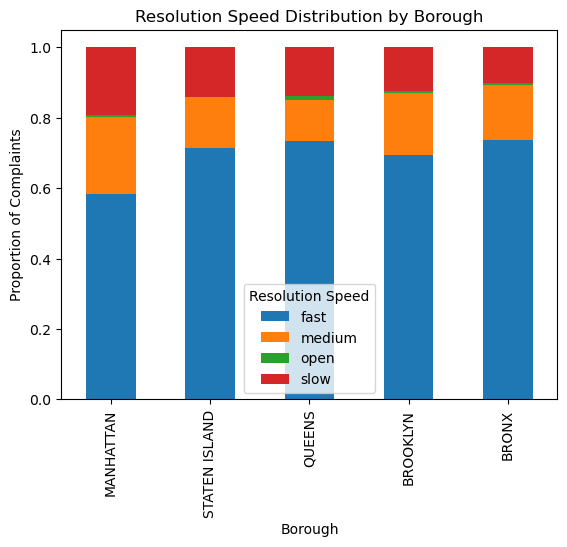

In [50]:
#resolution speed by borough (stacked bar)

speed_dist = NYC.groupby("borough")["resolution_speed"] \
    .value_counts(normalize=True) \
    .unstack()

#sort by highest proportion of slow complaints
speed_dist = speed_dist.sort_values(by="slow", ascending=False)

speed_dist.plot(kind="bar", stacked=True, )

plt.title("Resolution Speed Distribution by Borough")
plt.ylabel("Proportion of Complaints")
plt.xlabel("Borough")
plt.legend(title="Resolution Speed")
plt.show()

Resolution speed is broadly consistent across boroughs, with the majority of complaints being resolved quickly, indicating that NYC’s service system handles most cases efficiently regardless of location. However, the small but noticeable differences in the share of slow cases—particularly in Manhattan and Staten Island—suggest that certain boroughs face more complex or resource-intensive complaints that extend resolution times.

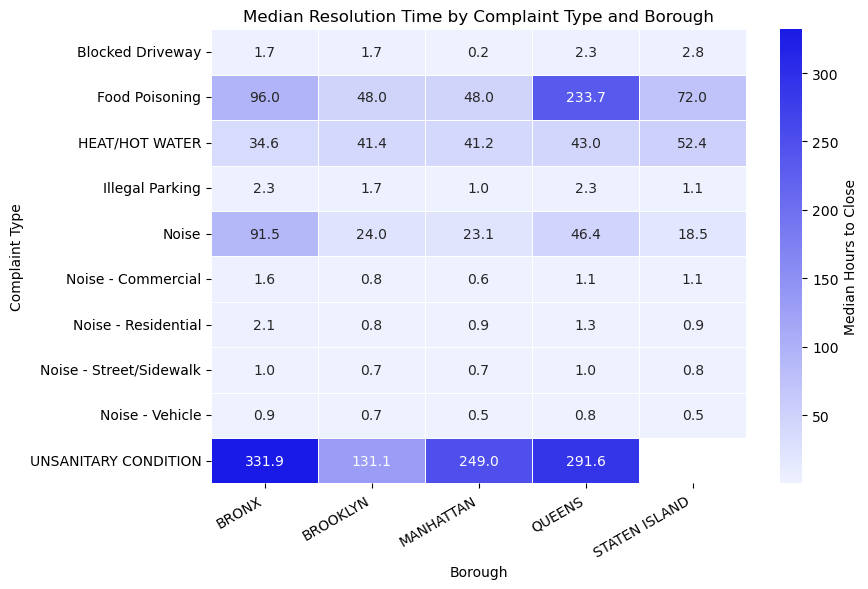

In [55]:
#heatmap of resolution time

custom_blues = LinearSegmentedColormap.from_list(
    "custom_blues",
    ["#eef2ff", "#1a1ae6"]
)

resolution_pivot = (
    NYC
    .groupby(["complaint_type", "borough"])["hours_to_close"]
    .median()
    .reset_index()
    .pivot(
        index="complaint_type",
        columns="borough",
        values="hours_to_close"
    )
)

top_types = [
    "Blocked Driveway",
    "Food Poisoning",
    "HEAT/HOT WATER",
    "Illegal Parking",
    "Noise",
    "Noise - Commercial",
    "Noise - Residential",
    "Noise - Street/Sidewalk",
    "Noise - Vehicle",
    "UNSANITARY CONDITION"
]

resolution_pivot = resolution_pivot.loc[
    resolution_pivot.index.isin(top_types)
]

resolution_pivot = resolution_pivot.reindex(top_types)

plt.figure(figsize=(9, 6))

sns.heatmap(
    resolution_pivot,
    annot=True,
    fmt=".1f",
    cmap=custom_blues,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Median Hours to Close"}
)

plt.title("Median Resolution Time by Complaint Type and Borough")
plt.xlabel("Borough")
plt.ylabel("Complaint Type")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("resolution_time_borough_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

The heatmap confirms that resolution time is driven far more by complaint type than by borough — the complaint-type variation dwarfs the borough variation. Practically, this means improving 311 resolution performance for NYC operations teams requires targeting the *types* of complaints most prone to delays, not redistributing resources between boroughs. A borough-neutral intervention focused on unsanitary condition and building/use workflows would have broader impact than any geographically targeted approach.


In [61]:
# Measure variation in resolution time across boroughs for top complaint types

top_types = (
    NYC["complaint_type"]
    .value_counts()
    .head(8)
    .index
)

borough_resolution = (
    NYC[NYC["complaint_type"].isin(top_types)]
    .groupby(["complaint_type", "borough"])
    .agg(
        sampled_volume=("unique_key", "count"),
        median_hours_to_close=("hours_to_close", "median")
    )
    .reset_index()
)

borough_resolution

,complaint_type,borough,sampled_volume,median_hours_to_close
0,Blocked Driveway,BRONX,70,1.700694
1,Blocked Driveway,BROOKLYN,127,1.705833
2,Blocked Driveway,MANHATTAN,3,0.170556
3,Blocked Driveway,QUEENS,188,2.283194
4,Blocked Driveway,STATEN ISLAND,4,2.835833
5,Food Poisoning,BRONX,172,96.000278
6,Food Poisoning,BROOKLYN,457,48.000278
7,Food Poisoning,MANHATTAN,841,48.000278
8,Food Poisoning,QUEENS,367,233.666667
9,Food Poisoning,STATEN ISLAND,58,72.000278


In [60]:
# Recalculate cross-borough variation for selected complaint types
# Includes UNSANITARY CONDITION even though it may not be in the top 8 by volume

selected_types = [
    "Noise - Residential",
    "Food Poisoning",
    "Illegal Parking",
    "HEAT/HOT WATER",
    "UNSANITARY CONDITION",
    "Blocked Driveway",
    "Noise",
    "Noise - Commercial",
    "Noise - Street/Sidewalk",
    "Noise - Vehicle"
]

borough_resolution = (
    NYC[NYC["complaint_type"].isin(selected_types)]
    .groupby(["complaint_type", "borough"])
    .agg(
        sampled_volume=("unique_key", "count"),
        median_hours_to_close=("hours_to_close", "median")
    )
    .reset_index()
)

variation_by_type = (
    borough_resolution
    .groupby("complaint_type")
    .agg(
        min_median_hours=("median_hours_to_close", "min"),
        max_median_hours=("median_hours_to_close", "max"),
        avg_median_hours=("median_hours_to_close", "mean"),
        std_median_hours=("median_hours_to_close", "std"),
        boroughs_observed=("borough", "nunique")
    )
    .reset_index()
)

variation_by_type["range_hours"] = (
    variation_by_type["max_median_hours"] -
    variation_by_type["min_median_hours"]
)

variation_by_type["coefficient_of_variation"] = (
    variation_by_type["std_median_hours"] /
    variation_by_type["avg_median_hours"]
)

variation_by_type = variation_by_type.sort_values(
    "range_hours",
    ascending=False
)

variation_by_type

,complaint_type,min_median_hours,max_median_hours,avg_median_hours,std_median_hours,boroughs_observed,range_hours,coefficient_of_variation
9,UNSANITARY CONDITION,131.138750,331.939722,250.921562,86.738746,4,200.800972,0.345681
1,Food Poisoning,48.000278,233.666667,99.533556,77.578371,5,185.666389,0.779419
4,Noise,18.500000,91.466667,40.693333,30.373224,5,72.966667,0.746393
2,HEAT/HOT WATER,34.581944,52.394722,42.515028,6.396852,5,17.812778,0.150461
0,Blocked Driveway,0.170556,2.835833,1.739222,0.995211,5,2.665278,0.572216
3,Illegal Parking,1.010417,2.315694,1.689000,0.617603,5,1.305278,0.365662
6,Noise - Residential,0.839167,2.051944,1.175056,0.523101,5,1.212778,0.445171
5,Noise - Commercial,0.620556,1.600833,1.046639,0.364750,5,0.980278,0.348497
8,Noise - Vehicle,0.532500,0.910556,0.698167,0.170901,5,0.378056,0.244786
7,Noise - Street/Sidewalk,0.736250,0.985556,0.845361,0.123010,5,0.249306,0.145511


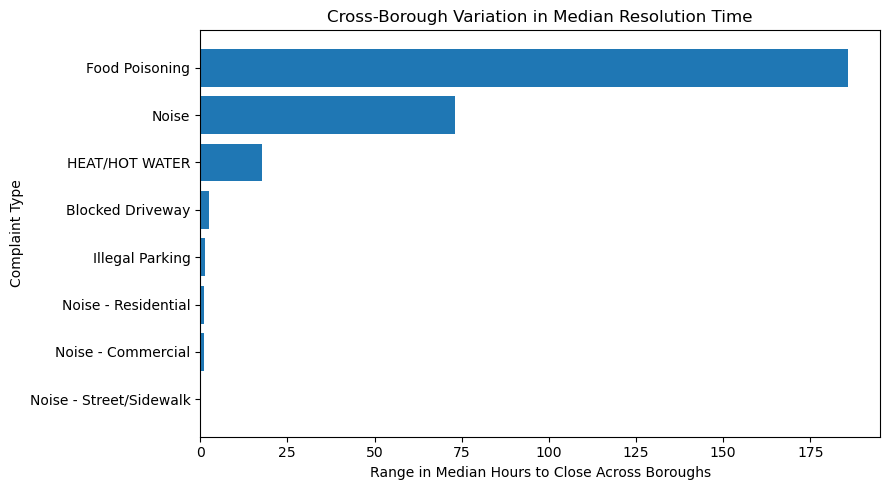

In [58]:
# Plot complaint types with the largest cross-borough variation

plt.figure(figsize=(9, 5))

plt.barh(
    variation_by_type["complaint_type"],
    variation_by_type["range_hours"]
)

plt.title("Cross-Borough Variation in Median Resolution Time")
plt.xlabel("Range in Median Hours to Close Across Boroughs")
plt.ylabel("Complaint Type")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("borough_resolution_variation.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#volume vs resolution time
complaint_stats = NYC.groupby("complaint_type").agg(
    avg_hours_to_close=("hours_to_close", "median"),
    volume=("complaint_type", "count")
).sort_values("volume", ascending=False)

complaint_stats.head(10)

The inverse relationship between volume and resolution time is a key structural finding: the complaints NYC receives most often (noise, illegal parking) are also the fastest to close, while the slowest-to-resolve complaints are relatively rare. This is important context for the modeling section — if we are trying to predict operationally difficult days, complaint *mix* (i.e., the proportion of slow-to-close types on a given day) is likely a more powerful predictor than raw complaint count.


In [ ]:
# Volume vs. resolution-time chart

import plotly.express as px

complexity_scatter = complaint_stats.copy().reset_index()

key_types = [
    "Noise - Residential",
    "Illegal Parking",
    "UNSANITARY CONDITION",
    "Food Poisoning",
    "HEAT/HOT WATER"
]

complexity_scatter["label"] = complexity_scatter["complaint_type"].where(
    complexity_scatter["complaint_type"].isin(key_types),
    ""
)

fig = px.scatter(
    complexity_scatter,
    x="volume",
    y="avg_hours_to_close",
    text="label",
    hover_name="complaint_type",
    hover_data={
        "volume": ":,",
        "avg_hours_to_close": ":.1f",
        "label": False
    },
    title="Volume vs. resolution-time chart",
    labels={
        "volume": "Sampled Complaint Volume",
        "avg_hours_to_close": "Median Hours to Close"
    }
)

fig.update_traces(
    marker=dict(size=10, opacity=0.65),
    textposition="top center"
)

fig.update_layout(
    width=900,
    height=600,
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()

High-volume complaint types are not always the slowest to resolve. Complaint volume and resolution complexity are not the same operational problem. Noise - Residential and Illegal Parking appear frequently but close quickly, while unsanitary conditions has much lower sampled volume but takes far longer to resolve. This suggests that staffing decisions based only on complaint volume may miss the real bottleneck: complex complaint workflows.

In [ ]:
plt.figure(figsize=(10,6))

NYC.boxplot(
    column="hours_to_close",
    by="borough",
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
    medianprops=dict(color="red"),
    flierprops=dict(marker='o', markersize=4, alpha=0.3)
)

plt.title("Distribution of Resolution Time by Borough")
plt.xlabel("Hours to Resolve")
plt.ylabel("Borough")
plt.suptitle("")  
plt.grid(axis='x', linestyle='--', alpha=0.5)

While median resolution times are similar across boroughs, all exhibit strong right skew with extreme outliers, indicating that a small number of complex cases drive most of the variability rather than differences in borough performance.

## 3. Seasonal Patterns in Complaints 
Are there seasonal or temporal patterns in complaint volume and resolution time across NYC boroughs?

In [ ]:
#complaint volume by month
true_daily_counts["month"] = pd.to_datetime(true_daily_counts["date_only"]).dt.month

true_monthly_volume = (
    true_daily_counts
    .groupby("month")["true_complaint_count"]
    .sum()
    .reset_index()
)

true_monthly_volume

In [ ]:
#complaint volume by month and hours to close

true_daily_counts["month"] = pd.to_datetime(true_daily_counts["date_only"]).dt.month

true_monthly_volume = (
    true_daily_counts
    .groupby("month")["true_complaint_count"]
    .sum()
    .reset_index()
)

monthly_resolution = (
    NYC.groupby("month")
    .agg(
        avg_hours_to_close=("hours_to_close", "mean"),
        median_hours_to_close=("hours_to_close", "median")
    )
    .reset_index()
)

monthly_summary = true_monthly_volume.merge(
    monthly_resolution,
    on="month",
    how="left"
)

monthly_summary

In [ ]:
# Graph Monthly Complaint Volume vs. Sampled Median Resolution Time

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for true complaint volume
ax1.bar(
    monthly_summary["month"],
    monthly_summary["true_complaint_count"],
    alpha=0.6
)
ax1.set_xlabel("Month")
ax1.set_ylabel("True Number of 311 Complaints", color="black")

# Line chart for sampled resolution time
ax2 = ax1.twinx()
ax2.plot(
    monthly_summary["month"],
    monthly_summary["median_hours_to_close"],
    color="red",
    marker="o"
)
ax2.set_ylabel("Sampled Median Hours to Close", color="red")

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.xticks(ticks=range(1, 13), labels=month_names)
plt.title("True Monthly Complaint Volume vs. Sampled Median Resolution Time")
plt.tight_layout()
plt.show()

True complaint volume varies by month, but the largest resolution-time spikes do not perfectly align with the highest-volume months — November, for example, has lower complaint volume but elevated median resolution time. This decoupling of volume and resolution speed supports the core finding that staffing strain is not simply proportional to complaint count. Instead, seasonal shifts in complaint *mix* (more heating complaints in winter, more heat/hot-water complaints in summer) bring structurally harder-to-close cases that drive delays independent of total workload.


In [ ]:
#top complaint types by month
NYC.groupby("month")["complaint_type"].value_counts().unstack()

In [ ]:
#complaints by borough and month

NYC_true.groupby(["borough", "month"])["true_complaint_count"].sum().unstack()

In [ ]:
NYC.groupby(["borough", "month"])["hours_to_close"].median().unstack()

In [ ]:
# Heatmap of true complaint volume by month and borough

pivot = (
    NYC_true
    .groupby(["month", "borough"])["true_complaint_count"]
    .sum()
    .unstack()
)

sns.heatmap(pivot, cmap="Blues")

plt.title("True Complaint Volume by Month and Borough")
plt.xlabel("Borough")
plt.ylabel("Month")
plt.show()

Complaint volume is broadly stable across months, but several boroughs show noticeably higher activity in summer months (particularly July–August), suggesting seasonally driven demand spikes rather than random variation. For operations planning, this implies that agencies should anticipate elevated complaint loads in summer — not as a citywide uniform increase, but concentrated in specific boroughs and complaint categories associated with heat (noise from outdoor activity, heat/hot-water failures, fodd posioning from spoiled food).


In [ ]:
# Top complaint types in the sampled complaint-level dataset
top_types = NYC["complaint_type"].value_counts().head(5).index

NYC_top = NYC[NYC["complaint_type"].isin(top_types)]

# Count sampled complaints by month and type
monthly_counts = NYC_top.groupby(["month", "complaint_type"]).size().unstack()

# Sort months
monthly_counts = monthly_counts.sort_index()

# Plot
monthly_counts.plot(marker="o", figsize=(10, 6))

# Replace x-axis labels with month names
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.xticks(ticks=range(1, 13), labels=month_names)

plt.title("Sampled Complaint Mix by Month for Top Complaint Types")
plt.xlabel("Month")
plt.ylabel("Number of Sampled Complaints")
plt.legend(title="Complaint Type")
plt.tight_layout()
plt.show()

In [ ]:
# True complaint volume by borough and month

borough_month = (
    NYC_true
    .groupby(["month", "borough"])["true_complaint_count"]
    .sum()
    .unstack()
)

# Sort months
borough_month = borough_month.sort_index()

# Plot
borough_month.plot(marker="o", figsize=(10, 6))

# Month labels
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.xticks(ticks=range(1, 13), labels=month_names)

plt.title("True Complaint Volume by Borough Across Months")
plt.xlabel("Month")
plt.ylabel("True Number of Complaints")
plt.legend(title="Borough")
plt.tight_layout()
plt.show()

The complaint mix shifts predictably by season: heating complaints surge in winter months (November–March) while noise complaints peak in summer. This seasonal rotation is operationally critical because heating and building/use complaints also have some of the longest median resolution times. In other words, winter months bring not just a different complaint type, but a structurally harder-to-close one — which helps explain why resolution times can be slower in winter even when total volume is lower than summer.


## 4. Normalizing Analysis Using Population:

Given each NYC borough has a different population size, we normalized complaint counts using borough-level population data from the US Census. To do so, we created the metric **Complaints per 100k** which is the mean complaints per 100k people in each borough.


In [ ]:
#Looking at absolute volume of complaints by borough
group_summary = (
    NYC_true
    .groupby("borough")["true_complaint_count"]
    .sum()
    .reset_index(name="complaint_count")
    .sort_values(by="complaint_count", ascending=False)
)

group_summary

Brooklyn has the highest absolute number of complaints, but we want to examine how population size impacts complaint volume.

In [ ]:
#Cleaning borough data to map on population
NYC['borough'] = NYC['borough'].str.strip().str.title()

In [ ]:
# Pull most recent population data by NYC borough
import requests

# Census API key
census_key = "343a0d2419297f42ced4c3642d15a4f23f975ff4"

borough_to_fips = {
    "Bronx": "005",
    "Brooklyn": "047",
    "Manhattan": "061",
    "Queens": "081",
    "Staten Island": "085"
}

census_url = "https://api.census.gov/data/2023/acs/acs5"

params = {
    "get": "NAME,B01003_001E",
    "for": "county:*",
    "in": "state:36",
    "key": census_key
}

response = requests.get(
    census_url,
    params=params,
    timeout=30
)

print(response.status_code)

resp = response.json()

population = pd.DataFrame(
    resp[1:],
    columns=resp[0]
)

population = population.rename(columns={
    "NAME": "county_name",
    "B01003_001E": "population",
    "county": "county_fips"
})

population["population"] = population["population"].astype(int)

population["borough"] = population["county_fips"].map({
    "005": "Bronx",
    "047": "Brooklyn",
    "061": "Manhattan",
    "081": "Queens",
    "085": "Staten Island"
})

population = population.dropna(subset=["borough"])

population[["borough", "population"]]

In [ ]:
# Find correct index for county FIPS
header = resp[0]
county_idx = header.index("county")
pop_idx = header.index("B01003_001E")

# Build county FIPS to population dict
fips_to_pop = {row[county_idx]: int(row[pop_idx]) for row in resp[1:]}

# Build borough_population dict
borough_population = {borough: fips_to_pop[fips] for borough, fips in borough_to_fips.items()}
borough_population

In [ ]:
# Mapping them together
NYC['population'] = NYC['borough'].map(borough_population)

In [ ]:
#Checking to see if it worked
NYC[['borough', 'population']].drop_duplicates()

In [ ]:
# Confirm all boroughs mapped successfully to Census population data

NYC[["borough", "population"]].drop_duplicates().sort_values("borough")

In [ ]:
NYC['population'].isna().sum()
#Checking to see if NA values match number of unspecified entries (it does)

In [ ]:
# Create borough-level summary using true complaint volume and Census population

# Pull one clean population row per borough from NYC
borough_population = (
    NYC[["borough", "population"]]
    .drop_duplicates()
    .sort_values("borough")
)

# Calculate true complaint volume by borough from NYC_true
true_borough_counts = (
    NYC_true
    .groupby("borough")["true_complaint_count"]
    .sum()
    .reset_index(name="borough_complaint_count")
)

# Merge true complaint counts with population
borough_summary = true_borough_counts.merge(
    borough_population,
    on="borough",
    how="left"
)

# Calculate complaints per 100k residents
borough_summary["complaints_per_100k"] = (
    borough_summary["borough_complaint_count"] /
    borough_summary["population"] *
    100000
)

# Sort by normalized complaint burden
borough_summary = borough_summary.sort_values(
    "complaints_per_100k",
    ascending=False
)

borough_summary

In [ ]:
# True complaints per 100k residents by borough

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(
    borough_summary["borough"],
    borough_summary["complaints_per_100k"]
)

ax1.set_xlabel("Borough")
ax1.set_ylabel("True Complaints per 100,000 Residents")
ax1.tick_params(axis="y")

ax2 = ax1.twinx()

ax2.plot(
    borough_summary["borough"],
    borough_summary["population"],
    color="red",
    marker="o"
)

ax2.set_ylabel("Population")
ax2.tick_params(axis="y")

plt.title("True Complaints per 100k by NYC Borough and Population")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Correlation between true complaint volume and population by borough

correlation = borough_summary["borough_complaint_count"].corr(
    borough_summary["population"]
)

print(f"Pearson correlation between total population and true total complaints: {correlation:.3f}")

In [ ]:
%pip install geopandas

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Read NYC borough boundaries
boro_map = gpd.read_file(
    "https://raw.githubusercontent.com/dwillis/nyc-maps/master/boroughs.geojson"
)

# Clean borough names from the map file
boro_map["borough"] = (
    boro_map["BoroName"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Clean borough names in borough_summary
borough_summary["borough"] = (
    borough_summary["borough"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Create dictionary from borough_summary
complaints_dict = dict(
    zip(
        borough_summary["borough"],
        borough_summary["complaints_per_100k"]
    )
)

# Map complaints per 100k onto each borough
boro_map["complaints_per_100k"] = boro_map["borough"].map(complaints_dict)

# Check that values mapped correctly
boro_map[["borough", "complaints_per_100k"]]

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

# Borough map 
boro_map = gpd.read_file(
    "https://raw.githubusercontent.com/dwillis/nyc-maps/master/boroughs.geojson"
)

boro_map["borough"] = (
    boro_map["BoroName"]
    .astype(str)
    .str.strip()
    .str.title()
)

borough_summary["borough"] = (
    borough_summary["borough"]
    .astype(str)
    .str.strip()
    .str.title()
)

complaints_dict = dict(
    zip(
        borough_summary["borough"],
        borough_summary["complaints_per_100k"]
    )
)

boro_map["complaints_per_100k"] = boro_map["borough"].map(complaints_dict)

# Nearby county outlines 
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip"
)

counties = counties.to_crs(boro_map.crs)

# Use only a tight crop around NYC
xmin, ymin, xmax, ymax = boro_map.total_bounds
pad_x = (xmax - xmin) * 0.15
pad_y = (ymax - ymin) * 0.15

nearby_counties = counties.cx[
    xmin - pad_x : xmax + pad_x,
    ymin - pad_y : ymax + pad_y
]

# Blue gradient
custom_cmap = LinearSegmentedColormap.from_list(
    "blue_gradient",
    ["#DCE6FF", "#2D1FE8"]
)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Background: neighboring regions as outlines only
nearby_counties.boundary.plot(
    ax=ax,
    color="#BDBDBD",
    linewidth=0.7
)

# Foreground: boroughs shaded by metric
boro_map.plot(
    column="complaints_per_100k",
    cmap=custom_cmap,
    edgecolor="black",
    linewidth=1.0,
    legend=True,
    ax=ax,
    missing_kwds={"color": "#D7DEDD"}
)

# Borough labels
for idx, row in boro_map.iterrows():
    plt.annotate(
        text=row["borough"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha="center",
        fontsize=9,
        color="black"
    )

# Keep the crop tight around the boroughs
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

plt.title("NYC 311 Complaints per 100,000 Residents by Borough")
plt.axis("off")
plt.show()

Complaint volume is strongly correlated with population, but controlling for population reveals a very different picture than absolute counts suggest. Brooklyn leads in total complaints, but the Bronx has the highest complaints per 100k residents — meaning Bronx residents file complaints at a disproportionately higher rate relative to their population. For NYC operations leadership, this reframes resource allocation: if per-capita burden is the right metric (i.e., equitable service delivery), the Bronx should receive prioritized attention, not simply the most populous boroughs.


### Analysis of Response Time, Controlling for Population:

In [ ]:
# Calculating mean response time and population by borough
mean_response_time = NYC.groupby('borough')['hours_to_close'].median().dropna()
borough_population = NYC.groupby('borough')['population'].mean().reindex(mean_response_time.index)

# Plot bar (mean response time) and line (population)
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar chart for mean response time
ax1.bar(mean_response_time.index, mean_response_time.values, label='Median Response Time')
ax1.set_xlabel('Borough')
ax1.set_ylabel('Median Response Time (hours)')
ax1.tick_params(axis='y')

# Line chart for population
ax2 = ax1.twinx()
ax2.plot(mean_response_time.index, borough_population.values, color='red', marker='o', label='Population (absolute)')
ax2.set_ylabel('Population')
ax2.tick_params(axis='y')

plt.title('Median Response Time and Absolute Population by NYC Borough')
plt.tight_layout()
plt.show()

In [ ]:
# Mean response time and population by borough
mean_response_time = NYC.groupby('borough')['hours_to_close'].mean().dropna()
borough_population = NYC.groupby('borough')['population'].mean().reindex(mean_response_time.index)

correlation = mean_response_time.corr(borough_population)
print(f"Pearson correlation between mean response time and absolute population: {correlation:.3f}")

Median response time is negatively correlated with population — larger boroughs trend toward faster resolution times, which may reflect the staffing advantages of high-density service areas. Staten Island's slower median response time despite its smaller population is a notable outlier: its geographic isolation from the rest of the city likely creates logistical friction (longer crew travel times, fewer nearby resources) that independently lengthens resolution times, particularly during adverse weather. A future analysis incorporating per-borough staffing data and agency deployment schedules would allow a more causal interpretation of this relationship.


## 5. Outlier Analysis:

The goal of this analysis is to dig into outliers in the data set.

In [ ]:
# Columns to show
cols_to_show = [col for col in ['borough', 'created_date', 'closed_date', 'hours_to_close'] if col in NYC.columns]

# Complaints with extremely high hours_to_close (> 8000 hours)
outlier_resolutions = NYC[NYC['hours_to_close'] > 8000]
outlier_resolutions[cols_to_show]

In [ ]:
# Count number of outlier complaints by borough
outlier_counts = outlier_resolutions['borough'].value_counts()
outlier_counts

In [ ]:
# Robustness check: cap extreme resolution times at the 99th percentile
cap = NYC["hours_to_close"].quantile(0.99)
NYC["hours_to_close_capped"] = NYC["hours_to_close"].clip(upper=cap)

print(f"99th percentile cap: {cap:.1f} hours")
print(f"Rows capped: {(NYC['hours_to_close'] > cap).sum()}")

In [ ]:
# Compare raw vs capped response times by borough
outlier_robustness = pd.DataFrame({
    "median_raw": NYC.groupby("borough")["hours_to_close"].median(),
    "median_capped": NYC.groupby("borough")["hours_to_close_capped"].median(),
    "mean_raw": NYC.groupby("borough")["hours_to_close"].mean(),
    "mean_capped": NYC.groupby("borough")["hours_to_close_capped"].mean(),
})

outlier_robustness

Capping extreme values has little impact on median resolution times but reduces mean resolution times, confirming that medians are more reliable for this skewed dataset. This also shows that the main findings are not solely driven by a few extreme cases. Even after capping extreme values, the relative differences in median resolution time across boroughs remain consistent, indicating that the main findings are not driven by outliers.

There are a number of extremely long resolution times (>8000 hours), with the majority taking place in Manhattan and Queens. This could be due to complexity of response due to crowded roadways (i.e. Manhattan) or pure square footage to cover (i.e. Queens). It is likely that these extreme response time values are dragging up the mean response time. To control for this, we repulled the information and swapped to median values.

In [ ]:
# Calculating mean response time and population by borough
median_response_time = NYC.groupby('borough')['hours_to_close'].median().dropna()
borough_population = NYC.groupby('borough')['population'].mean().reindex(mean_response_time.index)

# Plot bar (mean response time) and line (population)
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar chart for mean response time
ax1.bar(median_response_time.index, median_response_time.values, label='Median Response Time')
ax1.set_xlabel('Borough')
ax1.set_ylabel('Median Response Time (hours)')
ax1.tick_params(axis='y')

# Line chart for population
ax2 = ax1.twinx()
ax2.plot(median_response_time.index, borough_population.values, color='red', marker='o', label='Population (absolute)')
ax2.set_ylabel('Population')
ax2.tick_params(axis='y')

plt.title('Median Response Time and Absolute Population by NYC Borough')
plt.tight_layout()
plt.show()

The graph above highlights that the outliers are highly skewing response time values as suspected. Now, we will investigate what types of complaints are driving the outlier values.

In [ ]:
# For complaints with extreme response times (e.g., top 5% of hours_to_close)
threshold = NYC['hours_to_close'].quantile(0.95)
outliers = NYC[NYC['hours_to_close'] > threshold]

# Count complaint types among these outliers
complaint_type_counts = outliers['complaint_type'].value_counts()

complaint_type_counts

Unsanitary Condition and Building/Use complaints are driving the bulk of the top 5% of complaint resolution times. This could be due to those issues being harder to solve - ex. requiring cleaning and construction teams to come in and work on the property. This would explain the presence of these outliers in our data set.

In [ ]:
# Complaint volume by day of week

true_daily_counts["day_of_week"] = true_daily_counts["date_only"].dt.day_name()

day_pattern = (
    true_daily_counts
    .groupby("day_of_week")["true_complaint_count"]
    .sum()
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
)

plt.figure(figsize=(8, 5))
plt.bar(day_pattern.index, day_pattern.values)
plt.title("True Complaint Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("True Number of Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Complaint volume peaks mid-week (Tuesday–Thursday) and drops on weekends. This is operationally significant: if city agencies staff primarily on weekdays, mid-week surges represent the highest-pressure periods for resolution speed. The lower weekend volume may also partly explain why some complaint types show faster resolution — fewer total cases compete for the same staff. Below, we test whether weekend status is associated with faster resolution times for high-volume complaint types.


In [ ]:
# Weekend vs. weekday median resolution time for top complaint types
# is_weekend was engineered during data cleaning — here we use it analytically

weekend_res = (
    NYC[NYC['complaint_type'].isin(top_types)]
    .groupby(['complaint_type', 'is_weekend'])['hours_to_close']
    .median()
    .unstack()
    .rename(columns={0: 'Weekday', 1: 'Weekend'})
    .sort_values('Weekday', ascending=False)
)

weekend_res.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'coral'])
plt.title('Median Resolution Time: Weekday vs. Weekend by Complaint Type')
plt.ylabel('Median Hours to Close')
plt.xlabel('Complaint Type')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

weekend_res


For most high-volume complaint types, weekday and weekend resolution times are comparable, suggesting that staffing levels on weekends are sufficient to maintain similar throughput. Any complaint types showing substantially longer weekend resolution times would be candidates for weekend staffing adjustments.


In [ ]:
# Complaint volume by month

monthly = (
    true_daily_counts
    .groupby("month")["true_complaint_count"]
    .sum()
)

plt.figure(figsize=(8, 5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("True Complaint Volume by Month")
plt.xlabel("Month")
plt.ylabel("True Number of Complaints")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [ ]:
# Daily complaint volume over time

NYC_daily = true_daily_counts.rename(
    columns={"true_complaint_count": "complaints_per_day"}
).copy()

plt.figure(figsize=(10, 6))
plt.plot(
    NYC_daily["date_only"],
    NYC_daily["complaints_per_day"],
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("True Number of 311 Complaints")
plt.title("True NYC 311 Complaints per Day Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Identify high-volume outlier days using true daily complaint counts

NYC_daily = true_daily_counts.rename(
    columns={"true_complaint_count": "complaints_per_day"}
).copy()

mean = NYC_daily["complaints_per_day"].mean()
std = NYC_daily["complaints_per_day"].std()

outlier_threshold = mean + 2 * std

outlier_days = NYC_daily[
    NYC_daily["complaints_per_day"] > outlier_threshold
].copy()

print(f"Outlier threshold: {outlier_threshold:.0f} complaints")
outlier_days

In [ ]:
print("Mean:", mean)
print("Std:", std)
print("Threshold:", mean + 2*std)
print("Highest complaints in a day:", NYC_daily['complaints_per_day'].max())

In [ ]:
plt.hist(NYC_daily['complaints_per_day'], bins=20)
plt.xlabel('Complaints Per Day')
plt.ylabel('Number of Days')
plt.title('Histogram of Daily Complaints')
plt.show()

In [ ]:
outlier_days = NYC_daily[NYC_daily['complaints_per_day'] > mean + 1.5 * std]
print(outlier_days)

In [ ]:
top_days = NYC_daily.sort_values('complaints_per_day', ascending=False).head(5)
print(top_days)

In [ ]:
NYC_daily = true_daily_counts.rename(
    columns={"true_complaint_count": "complaints_per_day"}
).copy()

plt.figure(figsize=(10, 6))
plt.plot(NYC_daily['date_only'], NYC_daily['complaints_per_day'], color='dodgerblue', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Number of Complaints')
plt.title('NYC Complaints by Day')
plt.tight_layout()

In [ ]:
NYC_daily['day_of_month'] = pd.to_datetime(NYC_daily['date_only']).dt.day

In [ ]:
first_day_mean = NYC_daily[NYC_daily['day_of_month'] == 1]['complaints_per_day'].mean()
other_days_mean = NYC_daily[NYC_daily['day_of_month'] != 1]['complaints_per_day'].mean()

print(f"Mean complaints on 1st: {first_day_mean:.2f}")
print(f"Mean complaints on other days: {other_days_mean:.2f}")

In [ ]:
NYC.head()

In [ ]:
target_date = '2025-03-05'
exists_created = pd.to_datetime(target_date) in pd.to_datetime(NYC['created_date']).dt.normalize()
print(f"Is {target_date} present in NYC['created_date']?: {exists_created}")

In [ ]:
# Count complaints with borough 'Unspecified'
unspecified_count = (NYC['borough'].str.lower() == 'unspecified').sum()
print(unspecified_count)

In [ ]:
# Identify complaint types with the highest share of extreme delays

threshold = NYC["hours_to_close"].quantile(0.95)

NYC["is_outlier"] = NYC["hours_to_close"] > threshold

outlier_share_by_type = (
    NYC
    .groupby("complaint_type")["is_outlier"]
    .mean()
    .sort_values(ascending=False)
)

outlier_by_type = outlier_share_by_type.head(10)

outlier_by_type.plot(kind="barh")

plt.title("Complaint Types Driving Extreme Delays")
plt.xlabel("Share of Complaints in Top 5% Slowest")
plt.ylabel("Complaint Type")
plt.tight_layout()
plt.show()

In [ ]:
# Complexity map: volume, median resolution time, and extreme-delay share

complexity_plot = complaint_stats.copy().reset_index()

complexity_plot["outlier_share"] = (
    complexity_plot["complaint_type"]
    .map(outlier_share_by_type)
)

key_types = [
    "Noise - Residential",
    "Illegal Parking",
    "UNSANITARY CONDITION",
    "Food Poisoning",
    "HEAT/HOT WATER"
]

complexity_plot = complexity_plot[
    complexity_plot["complaint_type"].isin(key_types)
].copy()

plt.figure(figsize=(11, 7))

plt.scatter(
    complexity_plot["volume"],
    complexity_plot["avg_hours_to_close"],
    s=complexity_plot["outlier_share"] * 1800 + 120,
    alpha=0.75,
    color="#1a1ae6",
    edgecolors="black",
    linewidths=0.5
)

label_offsets = {
    "UNSANITARY CONDITION": (12, -6),
    "Food Poisoning": (12, 4),
    "HEAT/HOT WATER": (12, 4),
    "Illegal Parking": (12, 4),
    "Noise - Residential": (-90, 6)
}

for idx, row in complexity_plot.iterrows():
    dx, dy = label_offsets.get(row["complaint_type"], (10, 5))
    
    plt.annotate(
        row["complaint_type"],
        xy=(row["volume"], row["avg_hours_to_close"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        ha="left"
    )

plt.title("High-Volume Complaint Types Are Not Always the Slowest to Resolve")
plt.xlabel("Sampled Complaint Volume")
plt.ylabel("Median Hours to Close")

plt.xlim(0, complexity_plot["volume"].max() * 1.15)
plt.ylim(-10, complexity_plot["avg_hours_to_close"].max() * 1.15)

plt.grid(alpha=0.2)

plt.figtext(
    0.5,
    -0.02,
    "Bubble size = share of complaints in the top 5% slowest resolutions",
    ha="center",
    fontsize=9,
    color="gray"
)

plt.tight_layout()

plt.savefig("complexity_scatter.png", dpi=300, bbox_inches="tight")

plt.show()

complexity_plot.sort_values("avg_hours_to_close", ascending=False)

A small number of complaint types account for a disproportionate share of extreme delays, reinforcing that resolution time variability is driven by complexity rather than volume.

## NYC Complaints Data: Conclusion ###

This analysis finds that NYC 311 resolution times are shaped primarily by complaint type and borough dynamics, rather than overall complaint volume. While the number of complaints remains relatively stable throughout the year, the composition of complaints shifts seasonally, leading to periods of increased complexity and longer resolution times.

Resolution time is also highly skewed, with a small number of extreme cases driving much of the variation in average performance. As a result, median resolution time provides a more accurate view of the typical experience.

Overall, service delays in NYC 311 are not a function of how many complaints are received, but of what those complaints are and where they occur. This suggests that improving performance will require targeted strategies focused on high-complexity complaint types and borough-specific conditions, rather than broad increases in capacity.

# Integration of Weather Data to NYC Complaints Analysis 

#### Expanding the Analysis: External Drivers of Operational Strain

The earlier sections showed that complaint resolution patterns vary substantially across complaint categories, boroughs, and time periods. However, many operational pressures on city systems may also be influenced by external environmental conditions.

To investigate whether weather contributes to complaint surges or delayed response times, the next phase of the analysis integrates NOAA weather data with daily NYC complaint metrics.

In [ ]:
weather = pd.read_csv("4318524.csv")

weather.head()

In [ ]:
weather.info()
weather.columns

In [ ]:
weather_clean = weather[
    [
        "DATE",
        "PRCP",
        "SNOW",
        "SNWD",
        "TAVG",
        "TMAX",
        "TMIN",
        "AWND",
        "WT01",
        "WT02",
        "WT03",
        "WT06",
        "WT08"
    ]
].copy()

weather_clean.head()

In [ ]:
# Convert DATE to datetime and create date_only to match the NYC dataframe

weather_clean["DATE"] = pd.to_datetime(weather_clean["DATE"], errors="coerce")

weather_clean["date_only"] = weather_clean["DATE"].dt.date

weather_clean.head()

In [ ]:
# Rename columns so they are easier to understand

weather_clean = weather_clean.rename(columns={
    "PRCP": "precipitation",
    "SNOW": "snowfall",
    "SNWD": "snow_depth",
    "TAVG": "avg_temp",
    "TMAX": "max_temp",
    "TMIN": "min_temp",
    "AWND": "avg_wind_speed",
    "WT01": "fog",
    "WT02": "heavy_fog",
    "WT03": "thunder",
    "WT06": "glaze",
    "WT08": "smoke_haze"
})

weather_clean.head()

In [ ]:
# Check missing values

weather_clean.isna().sum()

In [ ]:
# Fill weather event flags with 0
# In NOAA data, these columns are usually 1 if the event happened and blank if it did not

event_cols = [
    "fog",
    "heavy_fog",
    "thunder",
    "glaze",
    "smoke_haze"
]

weather_clean[event_cols] = weather_clean[event_cols].fillna(0)

weather_clean[event_cols].head()

In [ ]:
# Fill missing avg_temp using the average of max_temp and min_temp

weather_clean["avg_temp"] = weather_clean["avg_temp"].fillna(
    (weather_clean["max_temp"] + weather_clean["min_temp"]) / 2
)

weather_clean.isna().sum()

In [ ]:
# Create weather feature flags

weather_clean["rainy_day"] = (weather_clean["precipitation"] > 0).astype(int)
weather_clean["snow_day"] = (weather_clean["snowfall"] > 0).astype(int)
weather_clean["snow_on_ground"] = (weather_clean["snow_depth"] > 0).astype(int)
weather_clean["hot_day"] = (weather_clean["max_temp"] >= 85).astype(int)
weather_clean["cold_day"] = (weather_clean["min_temp"] <= 32).astype(int)
weather_clean["windy_day"] = (weather_clean["avg_wind_speed"] >= weather_clean["avg_wind_speed"].quantile(0.75)).astype(int)

weather_clean.head()

In [ ]:
weather_clean.describe()

In [ ]:
weather_clean["date_only"].duplicated().sum()

In [ ]:
# Check date range

weather_clean["DATE"].min(), weather_clean["DATE"].max()

In [ ]:
# Final cleaned weather dataframe for merging

weather_final = weather_clean[
    [
        "date_only",
        "precipitation",
        "snowfall",
        "snow_depth",
        "avg_temp",
        "max_temp",
        "min_temp",
        "avg_wind_speed",
        "rainy_day",
        "snow_day",
        "snow_on_ground",
        "hot_day",
        "cold_day",
        "windy_day",
        "fog",
        "heavy_fog",
        "thunder",
        "glaze",
        "smoke_haze"
    ]
].copy()

weather_final.head()

# 1. Weather Data EDA

Before merging weather data with complaints, we examine the weather dataset on its own to understand the distribution of conditions throughout 2025. This validates our feature engineering choices — for example, confirming that 'extreme weather' days are genuinely rare rather than routine — and gives context for interpreting weather-complaint relationships later. The charts below are diagnostic; their operational relevance becomes clear in the merged analysis in Section 3.


In [ ]:
# Count weather event days

weather_final[
    ["rainy_day", "snow_day", "snow_on_ground", "hot_day", "cold_day", "windy_day"]
].sum()

In [ ]:
# Percent of days with each weather event

weather_event_rates = (
    weather_final[
        ["rainy_day", "snow_day", "snow_on_ground", "hot_day", "cold_day", "windy_day"]
    ]
    .mean()
    .sort_values(ascending=False)
)

weather_event_rates

In [ ]:
weather_clean.isna().sum()

In [ ]:
weather_clean.describe()

In [ ]:
# Monthly weather summary

weather_final["month"] = pd.to_datetime(weather_final["date_only"]).dt.month

monthly_weather = (
    weather_final
    .groupby("month")
    .agg(
        avg_temp=("avg_temp", "mean"),
        avg_precipitation=("precipitation", "mean"),
        total_precipitation=("precipitation", "sum"),
        total_snowfall=("snowfall", "sum"),
        avg_wind_speed=("avg_wind_speed", "mean"),
        rainy_days=("rainy_day", "sum"),
        snow_days=("snow_day", "sum")
    )
)

monthly_weather

In [ ]:
# Daily temperature over time

plt.figure(figsize=(10,6))

plt.plot(
    weather_clean["DATE"],
    weather_clean["avg_temp"]
)

plt.title("Average Daily Temperature in NYC (2025)")
plt.xlabel("Date")
plt.ylabel("Average Temperature")

plt.show()

In [ ]:
# Total precipitation by month

plt.figure(figsize=(10,6))
plt.bar(monthly_weather.index, monthly_weather["total_precipitation"])
plt.title("Total Precipitation by Month")
plt.xlabel("Month")
plt.ylabel("Total Precipitation")

plt.show()

In [ ]:
# Temperature distribution

plt.figure(figsize=(10,6))
plt.hist(weather_final["avg_temp"], bins=25)
plt.title("Distribution of Average Daily Temperature")
plt.xlabel("Average Temperature")
plt.ylabel("Number of Days")

plt.show()

In [ ]:
# Precipitation distribution

plt.figure(figsize=(10,6))

plt.hist(
    weather_clean["precipitation"],
    bins=30
)

plt.title("Distribution of Daily Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Rainy day frequency

weather_clean["rainy_day"].value_counts()

In [ ]:
weather_clean["rainy_day"].mean()

In [ ]:
weather_numeric = weather_clean[
    [
        "precipitation",
        "snowfall",
        "avg_temp",
        "max_temp",
        "min_temp",
        "avg_wind_speed"
    ]
]

corr = weather_numeric.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Weather Variable Correlations")

plt.show()

In [ ]:
# Define good weather days

weather_final["good_weather_day"] = (
    (weather_final["avg_temp"] >= 60) &
    (weather_final["avg_temp"] <= 78) &
    (weather_final["precipitation"] == 0) &
    (weather_final["snowfall"] == 0) &
    (weather_final["avg_wind_speed"] <= weather_final["avg_wind_speed"].quantile(0.75))
).astype(int)

weather_final["good_weather_day"].value_counts()

In [ ]:
good_weather_summary = weather_final["good_weather_day"].value_counts().reset_index()

good_weather_summary.columns = ["good_weather_day", "num_days"]

good_weather_summary

In [ ]:
weather_final["good_weather_day"].mean()

In [ ]:
# Graph good weather days across the year

plt.figure(figsize=(10, 6))

plt.scatter(
    weather_final["date_only"],
    weather_final["good_weather_day"],
    alpha=0.7
)

plt.title("Good Weather Days in NYC")
plt.xlabel("Date")
plt.ylabel("Good Weather Day")

plt.yticks([0, 1], ["Not Good", "Good"])
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Count good weather days by month

weather_final["month"] = pd.to_datetime(weather_final["date_only"]).dt.month

good_days_by_month = (
    weather_final
    .groupby("month")["good_weather_day"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.bar(
    good_days_by_month["month"],
    good_days_by_month["good_weather_day"]
)

plt.title("Number of Good Weather Days by Month")
plt.xlabel("Month")
plt.ylabel("Number of Good Weather Days")

plt.show()

Good weather days are not evenly spread across the year; they cluster in the summer with some milder spring and fall months as well.

In [ ]:
# Extreme weather day flag

weather_final["extreme_weather_day"] = (
    
    # Heavy rain
    (weather_final["precipitation"] >= 1.0) |
    
    # Meaningful snowfall
    (weather_final["snowfall"] >= 2.0) |
    
    # Very hot
    (weather_final["max_temp"] >= 90) |
    
    # Very cold
    (weather_final["min_temp"] <= 20) |
    
    # Very windy
    (weather_final["avg_wind_speed"] >= 15)

).astype(int)

In [ ]:
# Count extreme vs normal weather days

weather_final["extreme_weather_day"].value_counts()

In [ ]:
# Percent of days classified as extreme weather

weather_final["extreme_weather_day"].mean()

Only 40 days, or about 11% of the year, were classified as extreme weather days, meaning the threshold is selective enough to capture genuinely disruptive weather rather than ordinary rain or seasonal variation.

In [ ]:
# Count each type of weather flag

weather_final[
    ["rainy_day", "snow_day", "hot_day", "cold_day", "windy_day", "extreme_weather_day"]
].sum()

In [ ]:
# Create weather category

weather_final["weather_category"] = "Normal Weather"

weather_final.loc[
    weather_final["good_weather_day"] == 1,
    "weather_category"
] = "Good Weather"

weather_final.loc[
    weather_final["extreme_weather_day"] == 1,
    "weather_category"
] = "Extreme Weather"

In [ ]:
# Count days in each category

weather_category_counts = (
    weather_final["weather_category"]
    .value_counts()
    .reindex(["Good Weather", "Normal Weather", "Extreme Weather"])
)

weather_category_counts

In [ ]:
# Graph weather category counts

plt.figure(figsize=(10, 6))

plt.bar(
    weather_category_counts.index,
    weather_category_counts.values
)

plt.title("NYC Weather Days by Category")
plt.xlabel("Weather Category")
plt.ylabel("Number of Days")

plt.show()

In [ ]:
# By month

weather_final["month"] = pd.to_datetime(weather_final["date_only"]).dt.month

weather_category_monthly = (
    weather_final
    .groupby(["month", "weather_category"])
    .size()
    .unstack(fill_value=0)
)

weather_category_monthly = weather_category_monthly[
    ["Good Weather", "Normal Weather", "Extreme Weather"]
]

weather_category_monthly.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("NYC Weather Categories by Month")
plt.xlabel("Month")
plt.ylabel("Number of Days")
plt.xticks(rotation=0)

plt.show()

# 2. SQL Merge: Weather Data and NYC Complaint Data

In [ ]:
import sqlite3 as sq

In [ ]:
connection = sq.connect("nyc_weather_project.db")
cursor = connection.cursor()

In [ ]:
# Convert complex object columns into SQLite-safe strings

import json

def make_sqlite_safe(value):
    if isinstance(value, (dict, list)):
        return json.dumps(value)
    return value

NYC = NYC.map(make_sqlite_safe)

In [ ]:
NYC["created_date"] = NYC["created_date"].astype(str)
NYC["closed_date"] = NYC["closed_date"].astype(str)
NYC["date_only"] = NYC["date_only"].astype(str)

In [ ]:
# Make SQLite-safe copies with only the columns needed for the join/analysis

NYC_sql = NYC[
    [
        "unique_key",
        "date_only",
        "borough",
        "complaint_type",
        "hours_to_close",
        "resolution_speed"
    ]
].copy()

weather_sql = weather_final.copy()

NYC_sql["date_only"] = NYC_sql["date_only"].astype(str)
weather_sql["date_only"] = weather_sql["date_only"].astype(str)

NYC_sql["hours_to_close"] = pd.to_numeric(NYC_sql["hours_to_close"], errors="coerce")

In [ ]:
# Move cleaned NYC complaints and weather dataframes into SQLite

NYC_sql.to_sql(
    "nyc_complaints",
    connection,
    if_exists="replace",
    index=False
)

weather_sql.to_sql(
    "weather_final",
    connection,
    if_exists="replace",
    index=False
)

In [ ]:
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type = 'table';
""", connection)

In [ ]:
# Create daily complaint table in SQLite

true_daily_counts_sql = true_daily_counts.copy()
true_daily_counts_sql["date_only"] = true_daily_counts_sql["date_only"].astype(str)

true_daily_counts_sql.to_sql(
    "true_daily_counts",
    connection,
    if_exists="replace",
    index=False
)

pd.read_sql("SELECT * FROM true_daily_counts LIMIT 10;", connection)

In [ ]:
# Create sample-based daily resolution table 

query = """
DROP TABLE IF EXISTS daily_resolution_sample;
"""

cursor.execute(query)

query = """
CREATE TABLE daily_resolution_sample AS
SELECT
    date_only,
    COUNT(unique_key) AS sampled_complaint_count,
    AVG(hours_to_close) AS mean_hours_to_close
FROM nyc_complaints
GROUP BY date_only;
"""

cursor.execute(query)
connection.commit()

pd.read_sql("SELECT * FROM daily_resolution_sample LIMIT 10;", connection)

In [ ]:
# Create daily median resolution time in SQLite

query = """
DROP TABLE IF EXISTS daily_median;
"""

cursor.execute(query)

query = """
CREATE TABLE daily_median AS
WITH ranked AS (
    SELECT
        date_only,
        hours_to_close,
        ROW_NUMBER() OVER (
            PARTITION BY date_only
            ORDER BY hours_to_close
        ) AS row_num,
        COUNT(*) OVER (
            PARTITION BY date_only
        ) AS total_rows
    FROM nyc_complaints
    WHERE hours_to_close IS NOT NULL
)
SELECT
    date_only,
    AVG(hours_to_close) AS median_hours_to_close
FROM ranked
WHERE row_num IN (
    (total_rows + 1) / 2,
    (total_rows + 2) / 2
)
GROUP BY date_only;
"""

cursor.execute(query)
connection.commit()

pd.read_sql("SELECT * FROM daily_median LIMIT 10;", connection)

In [ ]:
# Join daily complaint count/mean with daily median

query = """
DROP TABLE IF EXISTS daily_complaints_full;
"""

cursor.execute(query)

query = """
CREATE TABLE daily_complaints_full AS
SELECT
    t.date_only,
    t.true_complaint_count AS complaint_count,
    r.sampled_complaint_count,
    r.mean_hours_to_close,
    dm.median_hours_to_close
FROM true_daily_counts AS t
LEFT JOIN daily_resolution_sample AS r
    ON t.date_only = r.date_only
LEFT JOIN daily_median AS dm
    ON t.date_only = dm.date_only;
"""

cursor.execute(query)
connection.commit()

pd.read_sql("SELECT * FROM daily_complaints_full LIMIT 10;", connection)

In [ ]:
# Join daily complaints with weather data

query = """
DROP TABLE IF EXISTS master_df;
"""

cursor.execute(query)

query = """
CREATE TABLE master_df AS
SELECT
    dc.date_only,
    dc.complaint_count,
    dc.mean_hours_to_close,
    dc.median_hours_to_close,

    wf.precipitation,
    wf.snowfall,
    wf.snow_depth,
    wf.avg_temp,
    wf.max_temp,
    wf.min_temp,
    wf.avg_wind_speed,

    wf.rainy_day,
    wf.snow_day,
    wf.snow_on_ground,
    wf.hot_day,
    wf.cold_day,
    wf.windy_day,
    wf.good_weather_day,

    wf.fog,
    wf.heavy_fog,
    wf.thunder,
    wf.glaze,
    wf.smoke_haze,

    wf.extreme_weather_day,
    wf.weather_category

FROM daily_complaints_full AS dc
LEFT JOIN weather_final AS wf
    ON dc.date_only = wf.date_only;
"""

cursor.execute(query)
connection.commit()

pd.read_sql("SELECT * FROM master_df LIMIT 10;", connection)

# 3. SQL EDA on Merged Dataset

In [ ]:
# Good vs bad weather days

pd.read_sql("""

SELECT
    good_weather_day,

    AVG(complaint_count) AS avg_complaints,

    AVG(mean_hours_to_close) AS avg_resolution_time,

    AVG(median_hours_to_close) AS median_resolution_time

FROM master_df

GROUP BY good_weather_day;

""", connection)

In [ ]:
# Rainy vs non-rainy days

pd.read_sql("""

SELECT
    rainy_day,

    AVG(complaint_count) AS avg_complaints,

    AVG(mean_hours_to_close) AS avg_resolution_time

FROM master_df

GROUP BY rainy_day;

""", connection)

In [ ]:
# Snow days

pd.read_sql("""

SELECT
    snow_day,

    AVG(complaint_count) AS avg_complaints,

    AVG(mean_hours_to_close) AS avg_resolution_time

FROM master_df

GROUP BY snow_day;

""", connection)

In [ ]:
# Impact of wind

pd.read_sql("""

SELECT
    windy_day,

    AVG(complaint_count) AS avg_complaints,

    AVG(mean_hours_to_close) AS avg_resolution_time

FROM master_df

GROUP BY windy_day;

""", connection)

In [ ]:
pd.read_sql("""

SELECT
    CASE
        WHEN avg_temp >= 80 THEN 'Hot'
        WHEN avg_temp <= 40 THEN 'Cold'
        ELSE 'Moderate'
    END AS temp_group,

    COUNT(*) AS num_days,

    AVG(complaint_count) AS avg_complaints,

    AVG(mean_hours_to_close) AS avg_resolution_time

FROM master_df

GROUP BY temp_group;

""", connection)

Overall, broad weather conditions such as rain, snow, wind do not appear to substantially change average complaint volume across NYC. Average resolution times and daily complaint counts remained relatively stable across weather categories, suggesting that weather alone is not a major driver of overall 311 demand.

In [ ]:
# Best days in NYC
pd.read_sql("""

SELECT
    date_only,

    complaint_count,

    median_hours_to_close,

    avg_temp,

    precipitation,

    avg_wind_speed

FROM master_df

WHERE good_weather_day = 1

ORDER BY
    complaint_count ASC,
    median_hours_to_close ASC

LIMIT 10;

""", connection)

In [ ]:
# Worst days in NYC

pd.read_sql("""

SELECT
    date_only,

    complaint_count,

    median_hours_to_close,

    avg_temp,

    precipitation,

    snowfall

FROM master_df

ORDER BY
    complaint_count DESC,
    median_hours_to_close DESC

LIMIT 10;

""", connection)

In [ ]:
# Monthly trend analysis

pd.read_sql("""

SELECT
    SUBSTR(date_only, 6, 2) AS month,

    AVG(complaint_count) AS avg_complaints,

    AVG(avg_temp) AS avg_temp,

    AVG(precipitation) AS avg_precipitation,

    AVG(mean_hours_to_close) AS avg_resolution_time

FROM master_df

GROUP BY month

ORDER BY month;

""", connection)

In [ ]:
# Create complaint day categories in SQL using percentiles

master_df_python = pd.read_sql("SELECT * FROM master_df;", connection)

volume_threshold = master_df_python["complaint_count"].quantile(0.75)
resolution_threshold = master_df_python["median_hours_to_close"].quantile(0.75)

master_df_python["complaint_day_category"] = "Normal Complaint Day"

master_df_python.loc[
    (master_df_python["complaint_count"] >= volume_threshold) &
    (master_df_python["median_hours_to_close"] >= resolution_threshold),
    "complaint_day_category"
] = "Bad Complaint Day"

master_df_python.loc[
    (master_df_python["complaint_count"] <= master_df_python["complaint_count"].quantile(0.25)) &
    (master_df_python["median_hours_to_close"] <= master_df_python["median_hours_to_close"].quantile(0.25)),
    "complaint_day_category"
] = "Good Complaint Day"

master_df_python.to_sql(
    "master_labeled",
    connection,
    if_exists="replace",
    index=False
)

master_df_python["complaint_day_category"].value_counts()

In [ ]:
# Check that the final merged dataset has the expected number of days

pd.read_sql("""
SELECT 
    COUNT(*) AS total_days
FROM master_labeled;
""", connection)

In [ ]:
# Save true borough-month complaint data into SQLite

NYC_true_sql = NYC_true.copy()

NYC_true_sql["date_only"] = NYC_true_sql["date_only"].astype(str)

NYC_true_sql.to_sql(
    "nyc_true",
    connection,
    if_exists="replace",
    index=False
)

pd.read_sql("SELECT * FROM nyc_true LIMIT 10;", connection)

In [ ]:
# Roll up true complaint volume by borough and month

pd.read_sql("""
SELECT
    borough,
    month,
    SUM(true_complaint_count) AS complaint_count,
    'Borough-Month Detail' AS summary_level
FROM nyc_true
GROUP BY borough, month

UNION ALL

SELECT
    borough,
    'All Months' AS month,
    SUM(true_complaint_count) AS complaint_count,
    'Borough Subtotal' AS summary_level
FROM nyc_true
GROUP BY borough

UNION ALL

SELECT
    'All Boroughs' AS borough,
    'All Months' AS month,
    SUM(true_complaint_count) AS complaint_count,
    'Grand Total' AS summary_level
FROM nyc_true

ORDER BY
    borough,
    month;
""", connection)

In [ ]:
# Count days by weather category

pd.read_sql("""
SELECT 
    weather_category, 
    COUNT(*) AS num_days
FROM master_labeled
GROUP BY weather_category
ORDER BY num_days DESC;
""", connection)

In [ ]:
# Cross-tab: weather category vs complaint day category

pd.read_sql("""
SELECT
    weather_category,
    complaint_day_category,
    COUNT(*) AS num_days
FROM master_labeled
GROUP BY
    weather_category,
    complaint_day_category
ORDER BY
    weather_category,
    complaint_day_category;
""", connection)

In [ ]:
# Average complaint metrics by weather and complaint category

pd.read_sql("""
SELECT
    weather_category,
    complaint_day_category,

    COUNT(*) AS num_days,
    AVG(complaint_count) AS avg_complaints,
    AVG(median_hours_to_close) AS avg_median_resolution,
    AVG(mean_hours_to_close) AS avg_mean_resolution,
    AVG(avg_temp) AS avg_temperature,
    AVG(precipitation) AS avg_precipitation

FROM master_labeled

GROUP BY
    weather_category,
    complaint_day_category

ORDER BY
    weather_category,
    complaint_day_category;
""", connection)

In [ ]:
# Compare complaint volume and resolution time by weather category

pd.read_sql("""
SELECT 
    weather_category,
    ROUND(AVG(complaint_count), 2) AS avg_daily_complaints,
    ROUND(AVG(median_hours_to_close), 2) AS avg_median_hours_to_close
FROM master_labeled
GROUP BY weather_category
ORDER BY avg_median_hours_to_close DESC;
""", connection)

In [ ]:
# Compare complaint volume and resolution time by complaint-day category

pd.read_sql("""
SELECT 
    complaint_day_category,
    ROUND(AVG(complaint_count), 2) AS avg_daily_complaints,
    ROUND(AVG(median_hours_to_close), 2) AS avg_median_hours_to_close
FROM master_labeled
GROUP BY complaint_day_category
ORDER BY avg_median_hours_to_close DESC;
""", connection)

In [ ]:
# Show highest-volume complaint days

pd.read_sql("""
SELECT 
    date_only,
    complaint_count,
    ROUND(median_hours_to_close, 2) AS median_hours_to_close,
    weather_category,
    complaint_day_category
FROM master_labeled
ORDER BY complaint_count DESC
LIMIT 10;
""", connection)

In [ ]:
# Show slowest-resolution complaint days

pd.read_sql("""
SELECT 
    date_only,
    complaint_count,
    ROUND(median_hours_to_close, 2) AS median_hours_to_close,
    weather_category,
    complaint_day_category
FROM master_labeled
ORDER BY median_hours_to_close DESC
LIMIT 10;
""", connection)

In [ ]:
# Best days: good weather + good complaint day

pd.read_sql("""
SELECT
    date_only,
    weather_category,
    complaint_day_category,
    complaint_count,
    median_hours_to_close,
    avg_temp,
    precipitation,
    avg_wind_speed

FROM master_labeled

WHERE weather_category = 'Good Weather'
  AND complaint_day_category = 'Good Complaint Day'

ORDER BY
    complaint_count ASC,
    median_hours_to_close ASC

LIMIT 10;
""", connection)

In [ ]:
# Worst days: extreme weather + bad complaint day

pd.read_sql("""
SELECT
    date_only,
    weather_category,
    complaint_day_category,
    complaint_count,
    median_hours_to_close,
    avg_temp,
    precipitation,
    snowfall,
    avg_wind_speed

FROM master_labeled

WHERE weather_category = 'Extreme Weather'
  AND complaint_day_category = 'Bad Complaint Day'

ORDER BY
    complaint_count DESC,
    median_hours_to_close DESC

LIMIT 10;
""", connection)

In [ ]:
# Rainy vs. non-rainy true complaint volume and sampled resolution time

pd.read_sql("""

SELECT
    rainy_day,
    COUNT(date_only) AS num_days,
    ROUND(AVG(complaint_count), 2) AS avg_true_daily_complaints,
    ROUND(AVG(mean_hours_to_close), 2) AS avg_sampled_hours_to_close,
    ROUND(AVG(median_hours_to_close), 2) AS median_sampled_hours_to_close
FROM master_df
WHERE median_hours_to_close IS NOT NULL
GROUP BY rainy_day
ORDER BY rainy_day DESC;

""", connection)

Rain does not materially change total 311 complaint volume or citywide resolution times — the system appears resilient to ordinary precipitation. This finding is useful for operations planning: routine rainy days do not require preemptive staffing surges. The more targeted question is whether *specific complaint types* slow down during rain, which is explored below.


In [ ]:
# Identify highest true complaint volume days and show their weather conditions

pd.read_sql("""

SELECT
    date_only,
    weather_category,
    rainy_day,
    hot_day,
    cold_day,
    snow_day,
    extreme_weather_day,
    complaint_count AS true_daily_complaints,
    ROUND(mean_hours_to_close, 2) AS sampled_avg_hours_to_close,
    ROUND(median_hours_to_close, 2) AS sampled_median_hours_to_close,
    RANK() OVER (
        ORDER BY complaint_count DESC
    ) AS complaint_volume_rank
FROM master_labeled
WHERE median_hours_to_close IS NOT NULL
ORDER BY complaint_volume_rank
LIMIT 15;

""", connection)

Some high complaint days overlap with extreme weather may cause short term operational strain, but pattern is not strong enough to make a meaningful conclusion about operational delays

In [ ]:
#Identifies complaint types that take longer to resolve on rainy days than they do overall.

pd.read_sql("""

SELECT
    c.complaint_type,
    COUNT(c.unique_key) AS rainy_day_complaints,
    ROUND(AVG(c.hours_to_close), 2) AS rainy_avg_hours_to_close,
    ROUND((
        SELECT AVG(c2.hours_to_close)
        FROM nyc_complaints c2
        WHERE c2.complaint_type = c.complaint_type
          AND c2.hours_to_close IS NOT NULL
    ), 2) AS overall_type_avg_hours_to_close,
    ROUND(
        AVG(c.hours_to_close) -
        (
            SELECT AVG(c2.hours_to_close)
            FROM nyc_complaints c2
            WHERE c2.complaint_type = c.complaint_type
              AND c2.hours_to_close IS NOT NULL
        ),
        2
    ) AS rainy_day_difference
FROM nyc_complaints c
JOIN weather_final w
    ON c.date_only = w.date_only
WHERE c.hours_to_close IS NOT NULL
  AND w.rainy_day = 1
GROUP BY c.complaint_type
HAVING COUNT(c.unique_key) >= 25
   AND AVG(c.hours_to_close) >
       (
           SELECT AVG(c2.hours_to_close)
           FROM nyc_complaints c2
           WHERE c2.complaint_type = c.complaint_type
             AND c2.hours_to_close IS NOT NULL
       )
ORDER BY rainy_day_difference DESC;

""", connection)

On rainy days, noise-related complaints take the longest (vs. average) to resolve. Correlation does not indicate causation, however, as rainy day resolution times for noise complaints may be related to operational prioritization, behavioral changes, etc.  A possible explanation, however, is that resource prioritization shifts to weather-related complaints (e.g., flooding, traffic) and low-priority complaints on noise take longer

In [ ]:
#Measures which complaint types increase disproportionately during extreme weather days

pd.read_sql("""

WITH overall_complaints AS (
    SELECT
        complaint_type,
        COUNT(*) AS overall_count
    FROM nyc_complaints
    GROUP BY complaint_type
),

extreme_weather_complaints AS (
    SELECT
        c.complaint_type,
        COUNT(*) AS extreme_count
    FROM nyc_complaints c
    JOIN weather_final w
        ON c.date_only = w.date_only
    WHERE w.extreme_weather_day = 1
    GROUP BY c.complaint_type
)

SELECT
    e.complaint_type,
    e.extreme_count,
    o.overall_count,
    ROUND(
        CAST(e.extreme_count AS FLOAT) / o.overall_count,
        3
    ) AS extreme_weather_ratio
FROM extreme_weather_complaints e
JOIN overall_complaints o
    ON e.complaint_type = o.complaint_type
WHERE o.overall_count >= 100
ORDER BY extreme_weather_ratio DESC
LIMIT 15;

""", connection)

This query measures how strongly each complaint type is associated with extreme weather overall. It calculates the share of a complaint type’s total complaints that occurred during extreme weather periods.

Heat/hot water and unsanitary condition complaints are disproportionately concentrated during extreme weather because heat places additional strain on residential infrastructure and accelerates sanitation-related issues such as spoilage, odors, and pest activity. Food poisoning complaints also rise during hotter conditions due to increased risks of food spoilage and refrigeration failures. In contrast, complaints tied to routine outdoor activity such as residential noise and illegal parking show weaker associations with extreme weather because disruptive conditions reduce overall outdoor movement and social activity.

In [ ]:
# Measures which complaint types increase disproportionately during extreme weather days, where normal day average >=3

extreme_weather_complaints = pd.read_sql("""

WITH daily_complaints AS (

    SELECT
        c.date_only,
        c.complaint_type,
        w.extreme_weather_day,
        COUNT(*) AS daily_count

    FROM nyc_complaints c

    JOIN weather_final w
        ON c.date_only = w.date_only

    GROUP BY
        c.date_only,
        c.complaint_type,
        w.extreme_weather_day
),

normal_weather_avg AS (

    SELECT
        complaint_type,
        ROUND(AVG(daily_count), 1) AS normal_day_avg

    FROM daily_complaints

    WHERE extreme_weather_day = 0

    GROUP BY complaint_type
),

extreme_weather_avg AS (

    SELECT
        complaint_type,
        ROUND(AVG(daily_count), 1) AS extreme_weather_avg

    FROM daily_complaints

    WHERE extreme_weather_day = 1

    GROUP BY complaint_type
)

SELECT
    e.complaint_type,
    n.normal_day_avg,
    e.extreme_weather_avg,

    ROUND(
        (
            (e.extreme_weather_avg - n.normal_day_avg)
            / n.normal_day_avg
        ) * 100,
        1
    ) AS pct_increase

FROM extreme_weather_avg e

JOIN normal_weather_avg n
    ON e.complaint_type = n.complaint_type

WHERE n.normal_day_avg >= 3

ORDER BY pct_increase DESC;

""", connection)

extreme_weather_complaints

This query uses daily averages to directly compare complaint activity between normal weather days and extreme weather days.

Extreme weather does not dramatically increase overall NYC 311 demand, but it does shift which complaint types dominate the system. Heat-related and sanitation-related complaints rise disproportionately during extreme weather conditions, while activity-driven complaints such as residential noise and illegal parking decline. This suggests that weather creates targeted operational pressure on specific city services rather than broad citywide overload.

In [ ]:
#Complaint types that slow down the most during rainy weather

pd.read_sql("""

SELECT
    c.complaint_type,

    ROUND(AVG(
        CASE
            WHEN w.rainy_day = 1
            THEN c.hours_to_close
        END
    ), 2) AS rainy_avg_hours,

    ROUND(AVG(
        CASE
            WHEN w.rainy_day = 0
            THEN c.hours_to_close
        END
    ), 2) AS non_rainy_avg_hours,

    ROUND(
        AVG(
            CASE
                WHEN w.rainy_day = 1
                THEN c.hours_to_close
            END
        )
        -
        AVG(
            CASE
                WHEN w.rainy_day = 0
                THEN c.hours_to_close
            END
        ),
        2
    ) AS rainy_delay_difference

FROM nyc_complaints c
JOIN weather_final w
    ON c.date_only = w.date_only

WHERE c.hours_to_close IS NOT NULL

GROUP BY c.complaint_type

HAVING COUNT(*) >= 50

ORDER BY rainy_delay_difference DESC
LIMIT 15;

""", connection)

Rain does not uniformly slow city operations, but plumbing and infrastructure-adjacent complaint types show meaningfully longer resolution times on rainy days. Plumbing complaints already carry long baseline resolution times due to technical complexity; rain likely exacerbates these by increasing the volume of plumbing-adjacent issues (drainage, leaks, flooding) simultaneously, creating a demand cluster that stretches the same specialized crews. The operational implication: agencies handling plumbing and water-infrastructure complaints should consider surge capacity protocols triggered by precipitation forecasts, not just actual rainfall.


In [ ]:
# Boroughs with the biggest weather-related slowdown, including sample size

pd.read_sql("""

SELECT
    c.borough,

    COUNT(*) AS sampled_complaints,

    SUM(CASE WHEN w.extreme_weather_day = 1 THEN 1 ELSE 0 END) AS extreme_weather_sampled_complaints,

    SUM(CASE WHEN w.extreme_weather_day = 0 THEN 1 ELSE 0 END) AS normal_weather_sampled_complaints,

    ROUND(AVG(
        CASE
            WHEN w.extreme_weather_day = 1
            THEN c.hours_to_close
        END
    ), 2) AS extreme_weather_hours,

    ROUND(AVG(
        CASE
            WHEN w.extreme_weather_day = 0
            THEN c.hours_to_close
        END
    ), 2) AS normal_weather_hours,

    ROUND(
        AVG(
            CASE
                WHEN w.extreme_weather_day = 1
                THEN c.hours_to_close
            END
        )
        -
        AVG(
            CASE
                WHEN w.extreme_weather_day = 0
                THEN c.hours_to_close
            END
        ),
        2
    ) AS weather_delay_difference

FROM nyc_complaints c
JOIN weather_final w
    ON c.date_only = w.date_only

WHERE c.hours_to_close IS NOT NULL
  AND c.borough IS NOT NULL
  AND c.borough != 'Unspecified'

GROUP BY c.borough

ORDER BY weather_delay_difference DESC;

""", connection)

Weather-related slowdowns are disproportionately concentrated in Staten Island, which experiences the largest increase in resolution time on extreme weather days relative to normal days. This aligns with its geographic characteristics: as NYC's least densely served borough and the only one not connected to the subway system, Staten Island's field crews face longer travel times and more limited backup resources during disruptive weather. For extreme weather planning, this suggests that Staten Island specifically would benefit from pre-positioned crew staging or dedicated weather-response protocols — rather than applying citywide surge plans that implicitly prioritize higher-density boroughs.


In [ ]:
# See whether bad complaint days tend to follow other bad complaint days

pd.read_sql("""

WITH lagged_days AS (

    SELECT
        date_only,
        complaint_day_category,

        LAG(complaint_day_category)
        OVER (ORDER BY date_only)
            AS previous_day_category

    FROM master_labeled
),

transition_counts AS (

    SELECT
        previous_day_category,
        complaint_day_category,
        COUNT(*) AS num_days
    FROM lagged_days
    WHERE previous_day_category IS NOT NULL
    GROUP BY
        previous_day_category,
        complaint_day_category
),

previous_day_totals AS (

    SELECT
        previous_day_category,
        SUM(num_days) AS total_days_after_previous_category
    FROM transition_counts
    GROUP BY previous_day_category
)

SELECT
    t.previous_day_category,
    t.complaint_day_category,
    t.num_days,
    ROUND(
        CAST(t.num_days AS FLOAT) / p.total_days_after_previous_category,
        3
    ) AS transition_share
FROM transition_counts t
JOIN previous_day_totals p
    ON t.previous_day_category = p.previous_day_category
ORDER BY
    t.previous_day_category,
    transition_share DESC;

""", connection)

Bad complaint days show meaningful short-term persistence: after a bad day, the probability of another bad day is approximately twice as high as the probability of a bad day following a normal day. However, bad days rarely extend into multi-day streaks — by day two, the system typically reverts toward normal operations. This is operationally useful as a leading indicator: if city operations teams observe a high-volume, slow-resolution day, they should anticipate elevated risk the following day and consider maintaining elevated staffing rather than immediately drawing down resources.


### Merged SQL EDA Conclusion

The merged weather-complaint analysis confirms that NYC's 311 system is broadly resilient to ordinary weather disruptions. Rain, wind, and moderate snow days produce complaint volumes and resolution times that appear broadly similar to fair-weather days in this descriptive analysis.

However, the data reveals three more targeted weather effects that have operational relevance:
1. **Extreme heat** disproportionately drives heat/hot-water, unsanitary condition, and food poisoning complaints — complaint types that also carry the longest baseline resolution times.
2. **Rain** specifically slows plumbing and water-infrastructure complaint resolution, likely because demand for those specialized crews spikes simultaneously with a precipitation event.
3. **Staten Island** is the most weather-sensitive borough for resolution delays, consistent with its geographic isolation.

These patterns suggest that weather-responsive operational planning should be targeted by *complaint type and borough*, not applied citywide — a blanket staffing surge on rainy days would not address the specific pressure points the data reveals.


# 4. Modeling: Linear & Logistic ##

### Weather Features and Operational Resolution Time ###
To build upon our EDA/SQL findings, we created predictive models that evaluate if weather conditions have a relationship with complaint resolution speed. We chose to focus on median_hours_to_close due to our earlier findings that complaint complexity seems to be a key driver of resolution speed. That said, we look the log of the median to reduce skewness.

#### Linear ####

In [ ]:
pd.read_sql("SELECT * FROM master_labeled;", connection)

In [ ]:
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression  

In [ ]:
master_df_python = pd.read_sql_query("""
SELECT *
FROM master_df;
""", connection)

In [ ]:
master_df_python

In [ ]:
linear_model_df = master_df_python.copy()

# Remove rows with missing target
linear_model_df = linear_model_df.dropna(subset=["complaint_count"])

# Keep useful columns
linear_model_df = linear_model_df[
    [
        "complaint_count",
        "median_hours_to_close",
        "precipitation",
        "snowfall",
        "snow_depth",
        "avg_temp",
        "max_temp",
        "min_temp",
        "avg_wind_speed",
        "rainy_day",
        "snow_day",
        "hot_day",
        "cold_day",
        "windy_day",
        "good_weather_day",
        "extreme_weather_day"
    ]
]

In [ ]:
features = [
    "precipitation",
    "snowfall",
    "snow_depth",
    "avg_temp",
    "avg_wind_speed",
    "rainy_day",
    "snow_day",
    "hot_day",
    "cold_day",
    "windy_day",
    "good_weather_day",
    "extreme_weather_day"
]

In [ ]:
linear_model_df[features].isna().sum().sort_values(ascending=False)

In [ ]:
linear_model_df[["snow_depth"]] = (
    linear_model_df[["snow_depth"]].fillna(0)
)

linear_model_df = linear_model_df.dropna(
    subset=["complaint_count"] + features
)

In [ ]:
linear_model_df[features].isna().sum().sort_values(ascending=False)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import statsmodels.api as sm
import numpy as np


In [ ]:
linear_model_df["log_median_hours"] = np.log1p(
    linear_model_df["median_hours_to_close"]
)

In [ ]:
X = linear_model_df[features]
y = linear_model_df["log_median_hours"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

In [ ]:
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

The linear model achieves an R² of approximately 0.35, meaning weather features explain about one-third of the variance in daily median resolution time. While modest, this is more predictive than a null model and confirms that weather does carry meaningful signal. The remaining ~68% of unexplained variance is likely attributable to factors not captured here: complaint type composition on a given day, staffing levels, agency-specific backlogs, and infrastructure conditions. This framing matters for NYC leadership: weather alone cannot predict bad operational days with high confidence, but it is a legitimate input to an early-warning system that also incorporates complaint mix and historical operational metrics.


In [ ]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lin_reg.coef_
}).sort_values("Coefficient")

coef_df

In [ ]:
# Create custom colors for coefficients

colors = []

for value in coef_df["Coefficient"]:
    
    # Negative coefficients
    if value < 0:
        colors.append("green")
        
    # Strong positive coefficients
    elif value >= 0.2:
        colors.append("red")
        
    # Small positive coefficients
    else:
        colors.append("gold")

# Create horizontal bar chart

plt.figure(figsize=(10, 6))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"],
    color=colors
)

plt.axvline(0, color='black', linewidth=1)

plt.title("Linear Regression Coefficients: Weather Predicting Median Hours to Close")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

# Save high-resolution chart
plt.savefig(
    "weather_regression_coefficients.png",
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
}).reset_index(drop=True)

comparison_df = comparison_df.sort_values("Actual").reset_index(drop=True)

plt.figure(figsize=(12,6))

plt.plot(comparison_df.index, comparison_df["Actual"], label="Actual Median Hours to Close")
plt.plot(comparison_df.index, comparison_df["Predicted"], label="Predicted Log Median Hours to Close")

plt.xlabel("Test Set Observation")
plt.ylabel("Median Hours to Close")
plt.title("Actual vs Predicted Log Median Hours to Close")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The actual vs. predicted plot shows the model tracks the central tendency of resolution time reasonably well but systematically underestimates extreme delays. This is expected: the most severe resolution slowdowns are driven by rare, complex cases (building emergencies, multi-agency sanitation interventions) that weather variables alone cannot anticipate. For practical use, the model is better treated as an index of *baseline operational risk* on a given day rather than a precise resolution-time forecast.


In [ ]:
# Use OLS to interpret the direction and statistical significance of weather variables

X_sm = sm.add_constant(X)

ols_model = sm.OLS(y, X_sm)
ols_results = ols_model.fit()

ols_results.summary()

The OLS summary shows that cold days and snowfall-related variables are positively associated with longer resolution times, consistent with the operational friction of winter conditions. However, some coefficients — including rainy_day — show negative or near-zero relationships, suggesting that ordinary rain does not independently delay resolution and may coincide with complaint mixes that are actually faster to close. The mixed directionality reinforces that weather is not a uniform operational stressor: extreme cold and snow create genuine strain, while moderate precipitation does not. Staffing interventions should therefore be calibrated to *winter severity* specifically, not to precipitation broadly.


### Logistic ###

We then used logistic regression to figure out if each day had an unusually slow resolution speed when compared to the median close time. Lastly, we used our same list of engineered features and compared that to our complaints classification to see if weather conditions impacted the probability of slow resolution days. 

Note: We explored feature scaling, but because many of our features were already in a binary form, this led to less interpretable results.

In [ ]:
linear_model_df["slow_resolution_day"] = (
    linear_model_df["median_hours_to_close"] >
    linear_model_df["median_hours_to_close"].median()
).astype(int)

linear_model_df["slow_resolution_day"].value_counts()

In [ ]:
X_log = linear_model_df[features]
y_log = linear_model_df["slow_resolution_day"]

X_train, X_test, y_train, y_test = train_test_split(
    X_log,
    y_log,
    test_size=0.2,
    random_state=42,
    stratify=y_log
)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    ConfusionMatrixDisplay
)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_log, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_log, zero_division=0))

The logistic regression model correctly classifies 71.2% of days as slow-resolution or normal. Precision of 75.9% means that when the model flags a slow day, it is right about three-quarters of the time — a useful signal-to-noise ratio for operational alerts. Recall of 61.1% means the model misses roughly 4 in 10 actual slow days; some slow days are driven entirely by non-weather factors (unusual complaint surges, staffing gaps) that these features cannot capture.

For operational deployment, this model is best framed as an *early-warning flag* rather than a definitive forecast: it narrows the probability space, but operations managers should combine its predictions with same-day complaint-mix data and staffing inputs before escalating response protocols.


In [ ]:
log_coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_reg.coef_[0]
}).sort_values("Coefficient")

log_coef_df

In [ ]:
log_coef_df.plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    figsize=(8,6)
)

plt.title("Logistic Regression Coefficients: Slow Resolution Days")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Cold days, extreme weather, and precipitation are the strongest positive predictors of slow-resolution days in the logistic model — consistent with the winter/extreme-heat findings from the EDA. Good weather days carry a negative coefficient, confirming that mild, dry conditions are associated with lower slow-resolution risk. Notably, the rainy_day binary flag has a near-zero or negative coefficient, reinforcing that routine rain is not an operational stressor — it is only in combination with extreme conditions that weather materially increases resolution risk.


In [ ]:
ConfusionMatrixDisplay.from_estimator(
    log_reg,
    X_test,
    y_test,
    display_labels=["Normal Day", "Slow Day"]
)

plt.title("Logistic Regression Confusion Matrix: Slow Resolution Days")
plt.show()


The confusion matrix shows the model is slightly stronger at identifying normal-resolution days (30/37 correct) than slow-resolution days (22/38 correct). The 16 false negatives — slow days the model classified as normal — are the highest-risk errors operationally: these are the days when city teams might not escalate resources but should. Many of these are likely driven by non-weather factors (unusual complaint surges, internal staffing issues) that the current feature set cannot capture. Incorporating complaint-mix features (e.g., share of slow-closing complaint types on that day) into a future model iteration would likely close this gap.


# Conclusion and Operational Implications


Overall, the analysis demonstrated that operational strain within NYC’s 311 complaint system is shaped by a combination of complaint composition, temporal patterns, and environmental conditions. In particular, the findings suggest that operationally difficult complaint days tend to show some short-term persistence over time rather than occurring randomly, with certain complaint categories and periods placing disproportionate pressure on city response systems.

Incorporating weather data expanded the analysis beyond complaint patterns alone and allowed for evaluation of whether environmental conditions contributed to service strain across NYC. While variables such as snowfall and extreme weather showed some statistically meaningful relationships with complaint activity and response delays, both the linear and logistic regression models demonstrated relatively modest predictive power overall. This suggests that weather contributes to complaint behavior, but does not fully explain operational performance.

The broader analysis indicates that complaint complexity, borough-level infrastructure differences, and operational resource constraints likely play a larger role in determining resolution speed than weather alone. Future work could improve predictive performance by incorporating additional datasets such as staffing levels, sanitation schedules, traffic congestion, socioeconomic indicators, infrastructure quality metrics, or real-time operational capacity data.

## Research Question Findings

This analysis directly addressed each of the five research questions posed at the outset:

**1. Which complaint categories contribute most to operational burden and delayed resolution times?**
Unsanitary conditions and building/use complaints account for the bulk of the top 5% of resolution times, driven by case complexity rather than volume. High-volume categories like noise and illegal parking close quickly.

**2. How do complaint patterns vary across boroughs, seasons, and time periods?**
Borough complaint mix reflects local infrastructure conditions more than population. Complaint volume is broadly stable year-round, but the *type* of complaint shifts seasonally: heating complaints dominate winter, noise and heat-related complaints dominate summer — and these seasonal mixes carry different resolution-time implications.

**3. Are high-volume or slow-response days isolated events, or do they cluster over time?**
Bad complaint days show short-term persistence: after a bad day, the probability of another bad day is approximately twice the baseline. However, multi-day streaks are rare — the system typically self-corrects within one day.

**4. Which complaint types are most sensitive to weather conditions?**
Heat/hot-water complaints spike sharply on extreme heat days. Plumbing complaints take meaningfully longer to resolve on rainy days. Noise complaints decrease on extreme weather days (fewer people outdoors). Broad weather events (ordinary rain, wind) do not materially affect most complaint categories.

**5. To what extent can weather and historical complaint patterns help predict operationally difficult days?**
A logistic regression using weather features achieves 71% accuracy in predicting slow-resolution days, with 76% precision. Weather explains ~32% of the variance in daily resolution time (linear model). Weather is a legitimate but insufficient predictor — complaint-type mix, staffing, and agency capacity are the dominant factors.

---

## Operational Recommendations for NYC Leadership

**1. Target unsanitary condition and building/use complaint workflows for intervention.**
These two categories generate the longest resolution times and the most extreme outliers. Process audits, pre-assigned inspection crews, and cross-agency coordination protocols for these specific types would have a larger impact on average resolution performance than broad capacity increases.

**2. Treat the Bronx as the highest per-capita burden borough for resource planning.**
Despite ranking below Brooklyn in absolute complaint volume, the Bronx generates the most complaints per 100,000 residents — making it the equity priority for service delivery. Budget and staffing allocations based solely on raw complaint counts will systematically underserve Bronx residents.

**3. Use the logistic model as a one-day-ahead early-warning signal.**
When today is a bad complaint day, the model predicts elevated risk tomorrow — giving operations managers a lead-time window to sustain staffing rather than draw down resources. Combined with a same-day complaint-mix feature (share of slow-closing types), this signal would become substantially more reliable.

**4. Pre-stage sanitation and housing inspection crews ahead of extreme heat forecasts.**
Heat/hot-water and unsanitary condition complaints spike disproportionately on extreme heat days. Because these categories already have long resolution baselines, an additional demand surge can compound delays significantly. Pre-positioning specialized crews before forecasted heat events (≥ 90°F) would flatten the response curve.

**5. Implement precipitation-triggered surge protocols specifically for plumbing/water complaints.**
Routine rain does not strain the system overall, but plumbing complaints slow substantially during rainy days. A targeted alert — rather than a citywide staffing surge — that pre-activates plumbing crew coverage on forecast rain days would address the specific bottleneck the data identifies.

**6. Develop dedicated weather-response protocols for Staten Island.**
Staten Island experiences the largest weather-related resolution slowdown of any borough, consistent with its geographic isolation. Pre-positioning field crews on the island ahead of major weather events, rather than dispatching from outer boroughs, would reduce the travel-time friction that likely drives its weather sensitivity.

---

## Future Work

Future analyses could substantially improve predictive accuracy by incorporating staffing data by borough and agency, open-workorder backlogs as a rolling feature, socioeconomic and infrastructure quality indicators by neighborhood, and real-time complaint-mix composition as a same-day model input. A more granular weather dataset (hourly rather than daily) could also surface within-day complaint patterns that the current analysis cannot detect.


# APPENDIX

In [ ]:
# Create figure
plt.figure(figsize=(10,6))

# Horizontal bar chart
sns.barplot(
    data=borough_summary,
    y="borough",
    x="complaints_per_100k"
)

# Titles and labels
plt.title("NYC 311 Complaints per 100k Residents by Borough")
plt.xlabel("True Complaints per 100k Residents")
plt.ylabel("Borough")

# Save high-resolution version for presentation
plt.savefig(
    "borough_complaints_per_100k.png",
    bbox_inches='tight',
    dpi=300
)
for index, value in enumerate(borough_summary["complaints_per_100k"]):
    plt.text(value + 20, index, f"{value:,.0f}")


plt.savefig("borough_chart.png",
            bbox_inches='tight',
            dpi=300)
    
# Show chart
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make borough comparison robust to capitalization
borough_summary["bar_color"] = borough_summary["borough"].str.upper().map(
    lambda x: "red" if x == "BRONX" else "gold"
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=borough_summary,
    y="borough",
    x="complaints_per_100k",
    hue="borough",
    palette=dict(zip(borough_summary["borough"], borough_summary["bar_color"])),
    dodge=False,
    legend=False
)

plt.title("NYC 311 Complaints per 100k Residents by Borough")
plt.xlabel("True Complaints per 100k Residents")
plt.ylabel("Borough")

for index, value in enumerate(borough_summary["complaints_per_100k"]):
    plt.text(value + 20, index, f"{value:,.0f}", va="center")

plt.savefig("borough_complaints_per_100k.png", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
# Graph weather category counts

plt.figure(figsize=(10, 6))

# Custom colors for each bar
colors = ["gold", "royalblue", "red"]

plt.bar(
    weather_category_counts.index,
    weather_category_counts.values,
    color=colors
)

plt.title("NYC Weather Days by Category")
plt.xlabel("Weather Category")
plt.ylabel("Number of Days")

# Save high-resolution chart
plt.savefig(
    "weather_category_counts.png",
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [ ]:
# By month

weather_final["month"] = pd.to_datetime(weather_final["date_only"]).dt.month

weather_category_monthly = (
    weather_final
    .groupby(["month", "weather_category"])
    .size()
    .unstack(fill_value=0)
)

weather_category_monthly = weather_category_monthly[
    ["Good Weather", "Normal Weather", "Extreme Weather"]
]

# Create bar chart with custom colors
weather_category_monthly.plot(
    kind="bar",
    figsize=(12, 5),
    color=["gold", "royalblue", "red"]
)

plt.title("NYC Weather Categories by Month")
plt.xlabel("Month")
plt.ylabel("Number of Days")
plt.xticks(rotation=0)

# Save high-resolution chart
plt.savefig(
    "weather_categories_by_month.png",
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [ ]:
# Compare complaint volume and resolution time by weather category

weather_summary = pd.read_sql("""
SELECT 
    weather_category,
    ROUND(AVG(complaint_count), 0) AS avg_daily_complaints,
    ROUND(AVG(median_hours_to_close), 0) AS avg_median_hours_to_close
FROM master_labeled
GROUP BY weather_category
ORDER BY avg_median_hours_to_close DESC;
""", connection)

# Convert to whole numbers
weather_summary["avg_daily_complaints"] = (
    weather_summary["avg_daily_complaints"].astype(int)
)

weather_summary["avg_median_hours_to_close"] = (
    weather_summary["avg_median_hours_to_close"].astype(int)
)

# Create export table
fig, ax = plt.subplots(figsize=(7.5, 2))

ax.axis('off')

table = ax.table(
    cellText=weather_summary.values,
    colLabels=weather_summary.columns,
    loc='center',
    colWidths=[0.38, 0.28, 0.34]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

# Save high-resolution version
plt.savefig(
    "weather_summary_table.png",
    bbox_inches='tight',
    dpi=300
)

plt.show()